# Image Data - Recognising Handwritten Alphabets

# SPRINT 1 - Create DataFrame from raw Image Files

# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os

from PIL import Image

# UNZIP the files

In [2]:
import zipfile
import os
from tqdm import tqdm

def unzip(zip_file_path, output_dir_path):
    with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        file_list = zip_ref.infolist()
        for file in tqdm(file_list, desc="Extracting files"):
            zip_ref.extract(file, output_dir_path)
    print("Data uncompressed successfully...")
    print()

zip_file_path = r"C:\Users\pc\Downloads\Mnist Project 3\mnist.zip"
output_dir_path = r"C:\Users\pc\Downloads\Mnist Project 3\mnist.images"

unzip(zip_file_path, output_dir_path)


Extracting files: 100%|███████████████████████████████████████████████████████| 372477/372477 [12:49<00:00, 484.19it/s]

Data uncompressed successfully...



#  Reading Images Files

In [2]:
path=r"C:\Users\mdmir\Downloads\Project 3\mnist.files\mist_images"

In [4]:
%%time

file_extensions = []
for root, dirs, files in os.walk(path):
    print(f"Reading images from {root}, Found {len(files)} files.")
    for file_name in files:
        file_extensions.append(os.path.splitext(file_name)[-1])
        file_path = os.path.join(root, file_name)

print()
print("Total Number of Files:", len(file_extensions))
print("File extensions:", set(file_extensions))

Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images, Found 0 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\A, Found 13870 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\B, Found 8668 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\C, Found 23409 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\D, Found 10134 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\E, Found 11440 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\F, Found 1163 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\G, Found 5762 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\H, Found 7218 files.
Reading images from C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images\I, Found 1120 files.
R

# Image  files to Dataframe

In [5]:
%%time

import os
from tqdm import tqdm
import pandas as pd
from PIL import Image


def read_image_files(path):
    images_data = []
    total_files = sum([len(files) for r, d, files in os.walk(path) if files])
    
    with tqdm(total=total_files, desc="Reading images") as pbar:
        for root, dirs, files in os.walk(path):
            for file_name in files:
                extension = os.path.splitext(file_name)[-1].lower()  # Ensure the extension is in lowercase
                if extension in file_extensions:
                    file_path = os.path.join(root, file_name)
                    try:
                        img = Image.open(file_path)
                        images_data.append({"file_name": file_name,
                                            "extension": extension, 
                                            "size": img.size, 
                                            "mode": img.mode, 
                                            "dir": root})
                    except Exception as e:
                        print(f"Error reading {file_path}: {e}")
                    pbar.update(1)
    return images_data

def load_into_df(images_data):
    df = pd.DataFrame(images_data)
    return df

# Read images and load into DataFrame
images_data = read_image_files(path)
df = load_into_df(images_data)

# Display the first few rows of the DataFrame
print(df.head())


Reading images: 100%|████████████████████████████████████████████████████████| 372451/372451 [03:23<00:00, 1831.20it/s]


    file_name extension      size mode  \
0     A-0.png      .png  (28, 28)    L   
1     A-1.png      .png  (28, 28)    L   
2    A-10.png      .png  (28, 28)    L   
3   A-100.png      .png  (28, 28)    L   
4  A-1000.png      .png  (28, 28)    L   

                                                 dir  
0  C:\Users\mdimr\Downloads\Project 3\mnist.files...  
1  C:\Users\mdimr\Downloads\Project 3\mnist.files...  
2  C:\Users\mdimr\Downloads\Project 3\mnist.files...  
3  C:\Users\mdimr\Downloads\Project 3\mnist.files...  
4  C:\Users\mdimr\Downloads\Project 3\mnist.files...  
CPU times: total: 1min 51s
Wall time: 3min 29s


In [6]:
df

,file_name,extension,size,mode,dir
0,A-0.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...
1,A-1.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...
2,A-10.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...
3,A-100.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...
4,A-1000.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...
...,...,...,...,...,...
372446,Z-995.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...
372447,Z-996.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...
372448,Z-997.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...
372449,Z-998.png,.png,"(28, 28)",L,C:\Users\mdimr\Downloads\Project 3\mnist.files...


In [7]:
df.to_csv(r"C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_csv")

In [3]:
img_df=pd.read_csv(r"C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_csv")

## File Extensions

In [5]:
print(img_df['extension'].value_counts()) 
print(img_df['size'].value_counts())
print(img_df['mode'].value_counts()) 

.png    372451
Name: extension, dtype: int64
(28, 28)    372451
Name: size, dtype: int64
L    372451
Name: mode, dtype: int64


## Size

In [10]:
img_df['size'].value_counts()

(28, 28)    372451
Name: size, dtype: int64

## Mode

In [11]:
img_df['mode'].value_counts() 

L    372451
Name: mode, dtype: int64

## Observations

1. There are 372451 images in total.

2. All these images are having **.png** format.

3. All these images are of same size i.e. **(28, 28)** and same mode i.e. **Gray Scale**

# Converting Pixels to Data Frame

In [11]:
import os
from tqdm import tqdm
import pandas as pd
from PIL import Image



def read_image_files(path):
    images_data = []
    first_dir_skipped = False
    label_count = {}

    total_files = sum([len(files) for r, d, files in os.walk(path) if files])

    with tqdm(total=total_files, desc="Reading images") as pbar:
        for root, dirs, files in os.walk(path):
            if not first_dir_skipped:
                first_dir_skipped = True
                continue

            dir_name = os.path.basename(root)
            dir_last_char = dir_name[-1]

            if dir_last_char not in label_count:
                label_count[dir_last_char] = 0

            files = [f for f in files if os.path.splitext(f)[-1].lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff']]
            for file_name in files:
                file_path = os.path.join(root, file_name)
                img = Image.open(file_path).convert('L')  # Convert image to grayscale
                img = img.resize((8, 8))  # Resize image to 8x8 pixels
                img_array = list(img.getdata())  # Get pixel data

                # Create a dictionary with pixel data and label
                img_data = {f'pixel{i}': img_array[i] for i in range(64)}
                img_data['label'] = dir_last_char

                images_data.append(img_data)
                label_count[dir_last_char] += 1
                pbar.update(1)
    return images_data

def load_into_df(images_data):
    df = pd.DataFrame(images_data)
    return df

# Read images and load into DataFrame
images_data = read_image_files(path)
df = load_into_df(images_data)

# Display the first few rows of the DataFrame
print(df.head())

# Save DataFrame to CSV
csv_file_path = "images_data.csv"  # Specify the path where you want to save the CSV file
df.to_csv(csv_file_path, index=False)
print(f"DataFrame saved to {csv_file_path}")


Reading images: 100%|████████████████████████████████████████████████████████| 372451/372451 [04:48<00:00, 1292.92it/s]


   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       1       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       1       0       0       0       0       0   

   pixel9  ...  pixel55  pixel56  pixel57  pixel58  pixel59  pixel60  pixel61  \
0       0  ...        0        0        0        0        0        0        1   
1       0  ...        0        0        0        0        0        2        0   
2       0  ...        0        0        0        0        0        0        0   
3       0  ...        0        0        0        0        0        0        0   
4       0  ...        0        0        0        0        0        0        0   

   pixel62  pixel63  label  
0        0        0  

In [2]:
path=r"C:\Users\mdimr\Downloads\Project 3\mnist.files\mist_images"

In [14]:
image_df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,A
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,A
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,A
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372446,0,0,0,0,0,0,0,0,2,51,...,0,0,0,0,0,0,0,0,0,Z
372447,0,7,12,12,12,6,8,0,0,69,...,0,0,4,4,0,0,0,3,0,Z
372448,0,7,7,0,0,0,0,0,0,81,...,0,0,2,7,1,0,0,0,0,Z
372449,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Z


In [12]:
image_df.to_csv(r"C:\Users\mdimr\Downloads\Project 3\mnist.files\mistpixel_csv")

# Loading Pixels Dataframe

In [2]:
df=pd.read_csv(r"C:\Users\mdimr\Downloads\Project 3\mnist.files\mistpixel_csv")

In [15]:
# Display the first few rows of the DataFrame
df.head()

,Unnamed: 0,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,A
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,A
2,2,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,A
4,4,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A


In [3]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [17]:
df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,A
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,A
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,A
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372446,0,0,0,0,0,0,0,0,2,51,...,0,0,0,0,0,0,0,0,0,Z
372447,0,7,12,12,12,6,8,0,0,69,...,0,0,4,4,0,0,0,3,0,Z
372448,0,7,7,0,0,0,0,0,0,81,...,0,0,2,7,1,0,0,0,0,Z
372449,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Z


In [18]:
# Display the DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372451 entries, 0 to 372450
Data columns (total 65 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   pixel0   372451 non-null  int64 
 1   pixel1   372451 non-null  int64 
 2   pixel2   372451 non-null  int64 
 3   pixel3   372451 non-null  int64 
 4   pixel4   372451 non-null  int64 
 5   pixel5   372451 non-null  int64 
 6   pixel6   372451 non-null  int64 
 7   pixel7   372451 non-null  int64 
 8   pixel8   372451 non-null  int64 
 9   pixel9   372451 non-null  int64 
 10  pixel10  372451 non-null  int64 
 11  pixel11  372451 non-null  int64 
 12  pixel12  372451 non-null  int64 
 13  pixel13  372451 non-null  int64 
 14  pixel14  372451 non-null  int64 
 15  pixel15  372451 non-null  int64 
 16  pixel16  372451 non-null  int64 
 17  pixel17  372451 non-null  int64 
 18  pixel18  372451 non-null  int64 
 19  pixel19  372451 non-null  int64 
 20  pixel20  372451 non-null  int64 
 21  pixel21  3

In [19]:
df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,A
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,A
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,A
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372446,0,0,0,0,0,0,0,0,2,51,...,0,0,0,0,0,0,0,0,0,Z
372447,0,7,12,12,12,6,8,0,0,69,...,0,0,4,4,0,0,0,3,0,Z
372448,0,7,7,0,0,0,0,0,0,81,...,0,0,2,7,1,0,0,0,0,Z
372449,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Z


In [20]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pixel0,372451.0,0.000720,0.043409,0.0,0.0,0.0,0.0,16.0
pixel1,372451.0,0.056450,0.495977,0.0,0.0,0.0,0.0,45.0
pixel2,372451.0,0.138426,0.912399,0.0,0.0,0.0,0.0,49.0
pixel3,372451.0,0.365801,1.535312,0.0,0.0,0.0,0.0,51.0
pixel4,372451.0,0.671868,2.017810,0.0,0.0,0.0,0.0,78.0
...,...,...,...,...,...,...,...,...
pixel59,372451.0,0.927091,2.416690,0.0,0.0,0.0,0.0,175.0
pixel60,372451.0,0.566311,1.996369,0.0,0.0,0.0,0.0,163.0
pixel61,372451.0,0.208908,1.285742,0.0,0.0,0.0,0.0,184.0
pixel62,372451.0,0.094786,0.762922,0.0,0.0,0.0,0.0,162.0


In [21]:
df.describe(include='object').T

,count,unique,top,freq
label,372451,26,O,57825


In [22]:
# Check for missing values
print(df.isnull().sum())

pixel0     0
pixel1     0
pixel2     0
pixel3     0
pixel4     0
          ..
pixel60    0
pixel61    0
pixel62    0
pixel63    0
label      0
Length: 65, dtype: int64


# Step 2 - Exploratory Data Analysis
## Univariate Analysis

# Bar Chart of Image Distribution by Label with Highlights

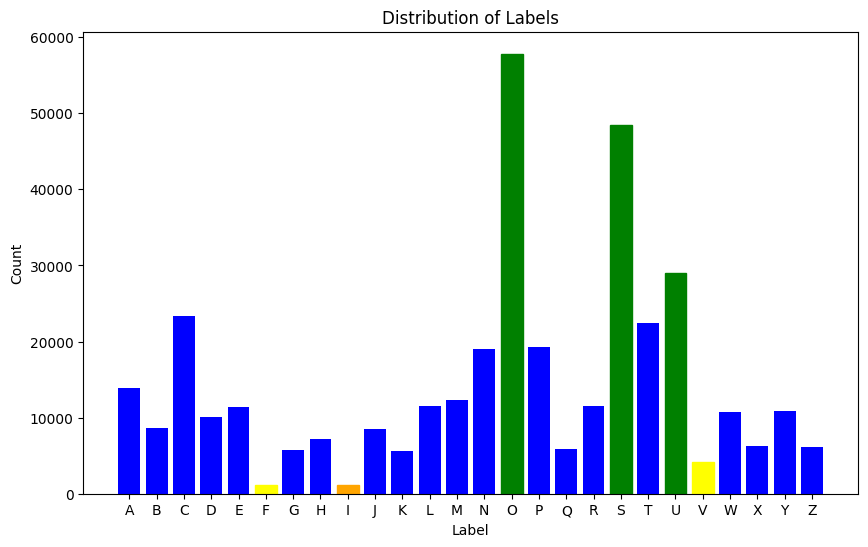

In [9]:
import matplotlib.pyplot as plt

# Count of images per label
label_counts = df['label'].value_counts()

# Sort labels alphabetically
label_counts = label_counts.sort_index()

# Plot the distribution of labels
plt.figure(figsize=(10, 6))
bars = plt.bar(label_counts.index, label_counts.values, color='blue')

# Highlight top 3 labels with green, bottom 3 labels with yellow, and the lowest label with orange
sorted_counts = label_counts.sort_values(ascending=False)
top_3_labels = sorted_counts.head(3).index
bottom_3_labels = sorted_counts.tail(3).index
lowest_label = sorted_counts.tail(1).index[0]

for bar, label in zip(bars, label_counts.index):
    if label in top_3_labels:
        bar.set_color('green')
    elif label in bottom_3_labels:
        bar.set_color('yellow')
    if label == lowest_label:
        bar.set_color('orange')

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.show()

## Observation
* The bar chart displays the distribution of images across different labels with specific highlights:

* **Top 3 Labels (Green):** s, o, u are the most frequent labels, with s having the highest count, followed by o and u. These labels are over-represented in the dataset.

* **Bottom 3 Labels (Yellow):** f, i, v are the least frequent labels, with f having the lowest count. These labels are under-represented in the dataset.

* **Lowest Label (Orange):** f has the fewest images, indicating a potential imbalance in the dataset.

# Visualization of Sample Images for Each Label

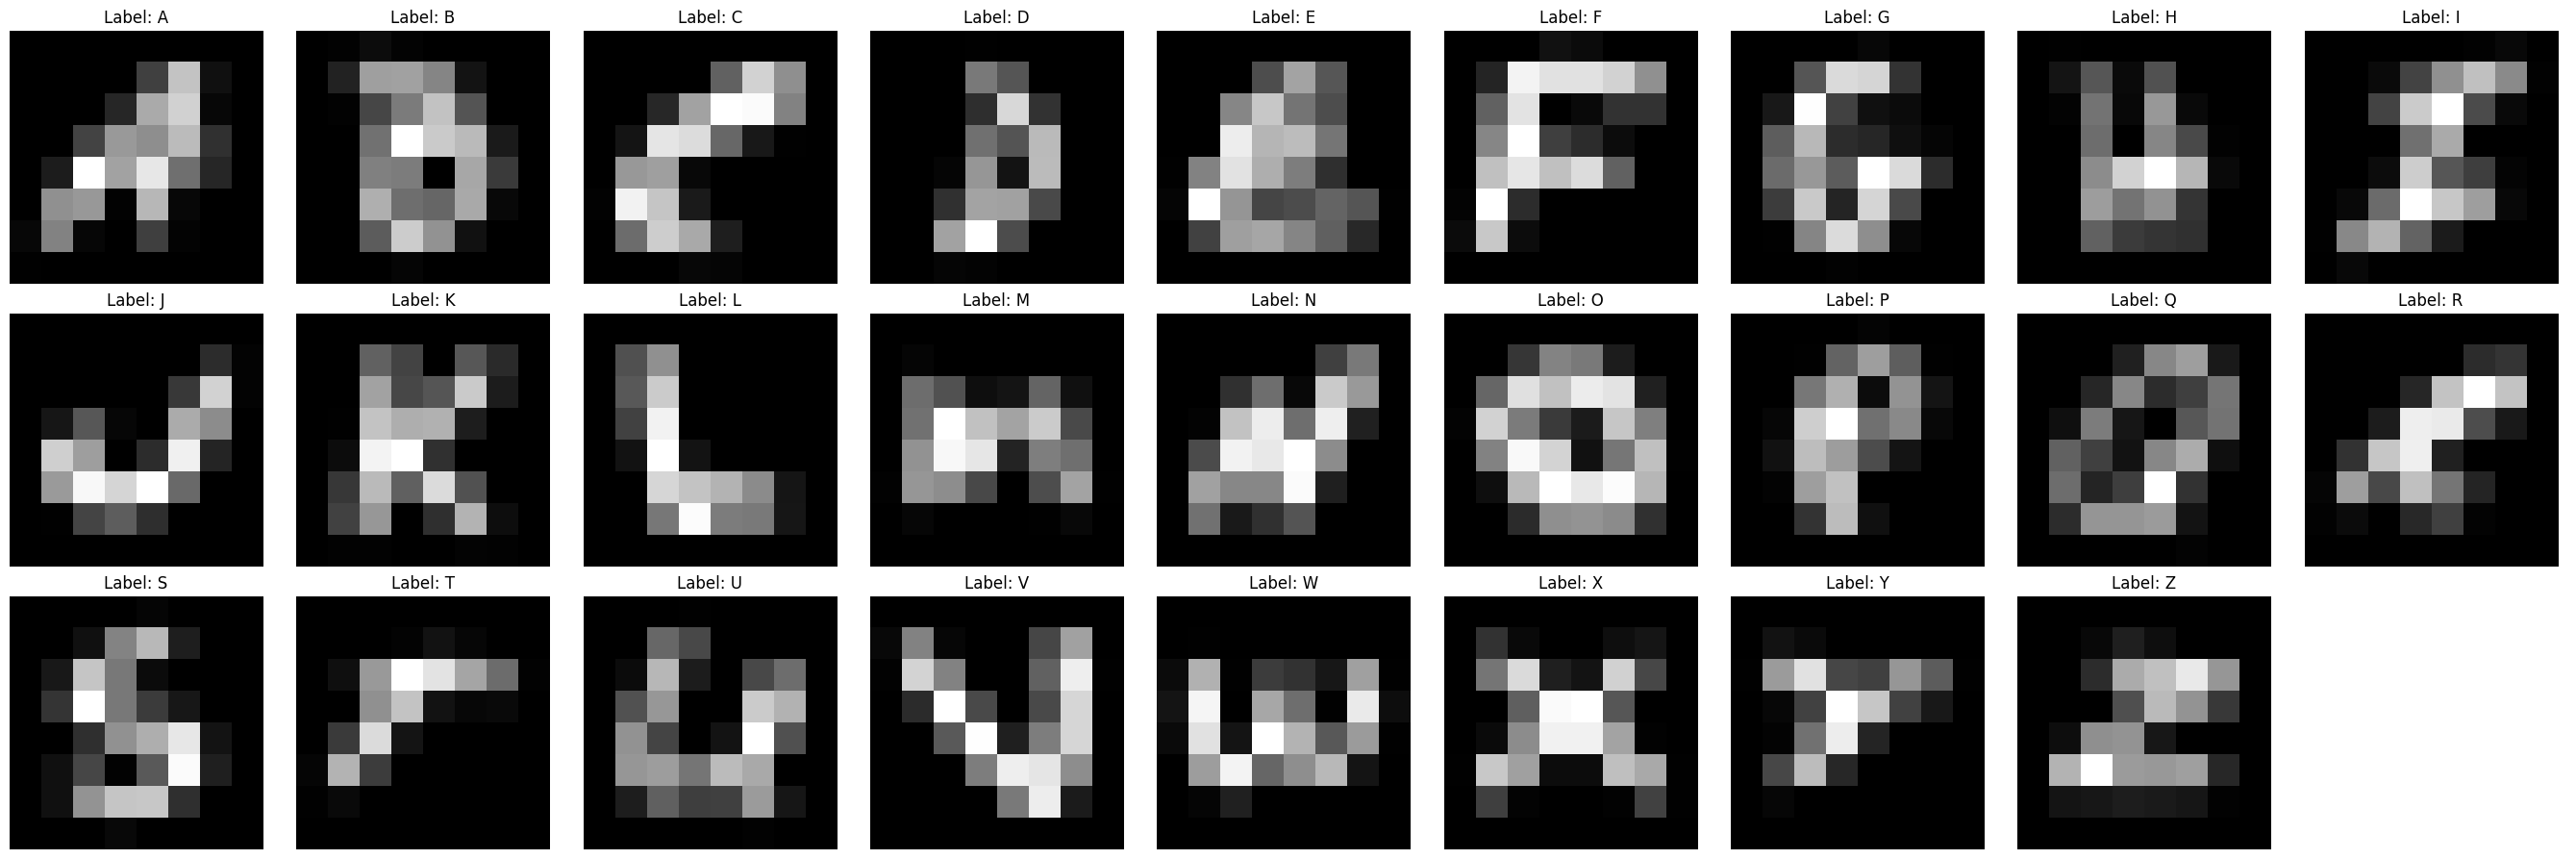

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sample_images(df):
    # Get the list of unique labels sorted alphabetically
    labels = sorted(df['label'].unique())
    
    # Ensure we have exactly 26 labels
    if len(labels) != 26:
        raise ValueError(f"Expected 26 labels, but found {len(labels)}")
    
    # Number of labels (should be 26 for the English alphabet)
    num_labels = len(labels)
    
    # Number of rows and columns for the grid
    num_rows = 3
    num_cols = (num_labels + num_rows - 1) // num_rows  # Calculate columns needed to fit 3 rows

    # Create a figure with subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 3))  # Increased size for images
    axes = axes.flatten()  # Flatten the 2D array of axes into a 1D array for easy iteration
    
    # Loop through each label and display one image
    for i, label in enumerate(labels):
        sample_image = df[df['label'] == label].sample(1).index[0]  # Select one sample image
        img_data = np.array([df.loc[sample_image, f'pixel{k}'] for k in range(64)]).reshape(8, 8)
        axes[i].imshow(img_data, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Label: {label}', fontsize=12)  # Increased font size for readability
    
    # Hide any unused subplots
    for j in range(len(labels), len(axes)):
        axes[j].axis('off')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

# Call the function to display the sample images
plot_sample_images(df)


## Observation
* The visualization shows one sample image for each letter of the alphabet:

* **Diverse Styles:** Images vary in style and clarity.
* **Clear Examples:** Most letters are well-represented.
* **Alphabet Display:** Shows samples from A to Z.

# Histogram of Pixel Intensities

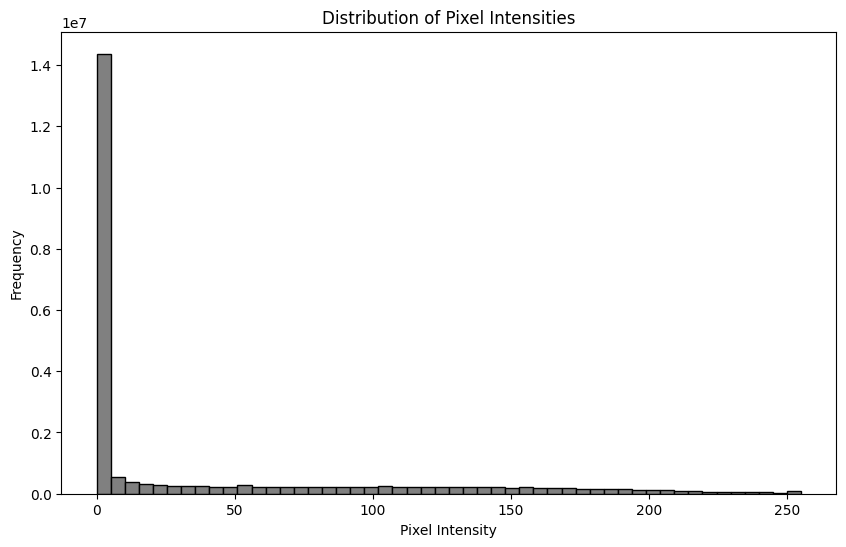

In [11]:
# Plot histogram of pixel intensities
plt.figure(figsize=(10, 6))
pixels = df.drop(columns=['label']).values.flatten()
plt.hist(pixels, bins=50, color='gray', edgecolor='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Distribution of Pixel Intensities')
plt.show()


## Observation 
* The histogram of pixel intensities reveals:

* **Highest Intensity:** Pixel value 0 (black) is the most frequent with a peak near 1.4.
* **Lowest Intensity:**  Pixel values between 200 and 250 (white) are least frequent, with a near-zero occurrence.
* The majority of pixels are dark, while lighter pixels are rare.



# Bivariant Analysis

## Distribution of Pixel Value Distance from Mean for Each Label

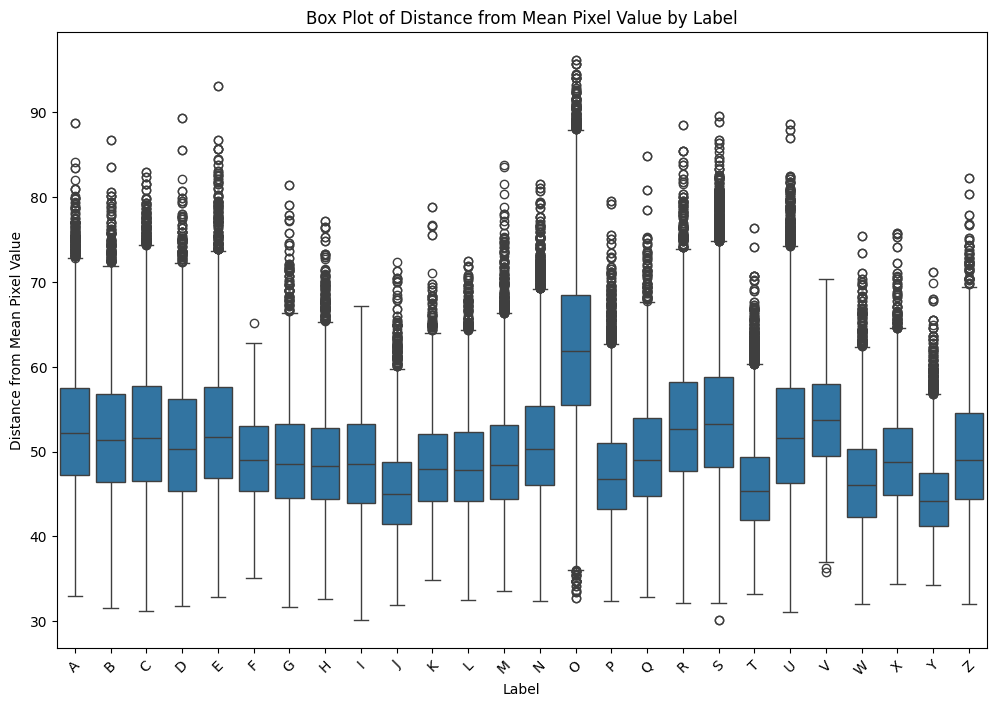

In [12]:
pixel_columns = [f'pixel{i}' for i in range(64)]
mean_pixel_value = df[pixel_columns].values.mean()

# Step 3: Calculate the distance from the mean pixel value
# Calculate the absolute difference from the mean pixel value for each pixel
df['Distance from Mean'] = df[pixel_columns].apply(lambda row: np.abs(row - mean_pixel_value).mean(), axis=1)

# Step 4: Prepare data for plotting
# 'Label' is already in the DataFrame, we will use it for grouping in the plot
plot_data = df[['Distance from Mean', 'label']]

# Step 5: Create the box plot
plt.figure(figsize=(12, 8))
sns.boxplot(x='label', y='Distance from Mean', data=plot_data)
plt.title('Box Plot of Distance from Mean Pixel Value by Label')
plt.xlabel('Label')
plt.ylabel('Distance from Mean Pixel Value')
plt.xticks(rotation=45)  # Rotate x labels if needed for better readability
plt.show()

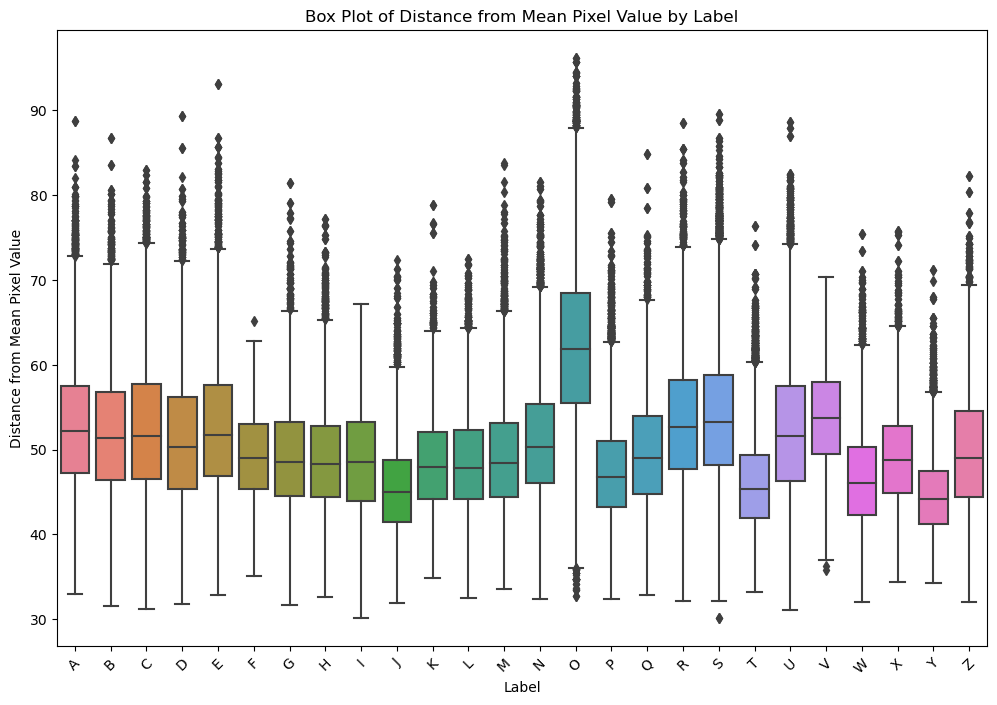

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pixel_columns = [f'pixel{i}' for i in range(64)]
mean_pixel_value = df[pixel_columns].values.mean()

# Step 3: Calculate the distance from the mean pixel value
# Calculate the absolute difference from the mean pixel value for each pixel
df['Distance from Mean'] = df[pixel_columns].apply(lambda row: np.abs(row - mean_pixel_value).mean(), axis=1)

# Define color palette
palette = sns.color_palette("husl", len(df['label'].unique()))  # Example palette

# Prepare data for plotting
plot_data = df[['Distance from Mean', 'label']]

# Create the box plot with colors
plt.figure(figsize=(12, 8))
sns.boxplot(x='label', y='Distance from Mean', data=plot_data, palette=palette)
plt.title('Box Plot of Distance from Mean Pixel Value by Label')
plt.xlabel('Label')
plt.ylabel('Distance from Mean Pixel Value')
plt.xticks(rotation=45)  # Rotate x labels if needed for better readability
plt.show()


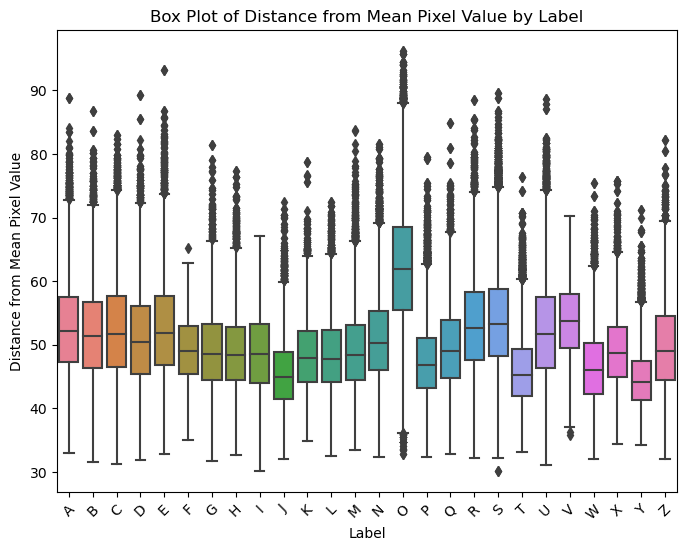

In [14]:
# Calculate the mean pixel value
pixel_columns = [f'pixel{i}' for i in range(64)]
mean_pixel_value = df[pixel_columns].values.mean()

# Calculate the distance from the mean pixel value
df['Distance from Mean'] = df[pixel_columns].apply(lambda row: np.abs(row - mean_pixel_value).mean(), axis=1)

# Define color palette
palette = sns.color_palette("husl", len(df['label'].unique()))  # Example palette

# Prepare data for plotting
plot_data = df[['Distance from Mean', 'label']]

# Create a smaller box plot with colors
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='Distance from Mean', data=plot_data, palette=palette)
plt.title('Box Plot of Distance from Mean Pixel Value by Label')
plt.xlabel('Label')
plt.ylabel('Distance from Mean Pixel Value')
plt.xticks(rotation=45)  # Rotate x labels if needed for better readability
plt.show()

## Observation
* **Variability:** Different labels have varying pixel value ranges.
* **Outliers:** Some labels have extreme values.
* **Median Differences:** Shows how labels deviate from the mean.

## PCA for Dimensionality Reduction and Visualization of Image Data

C:\Users\mdimr\.conda\envs\project\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


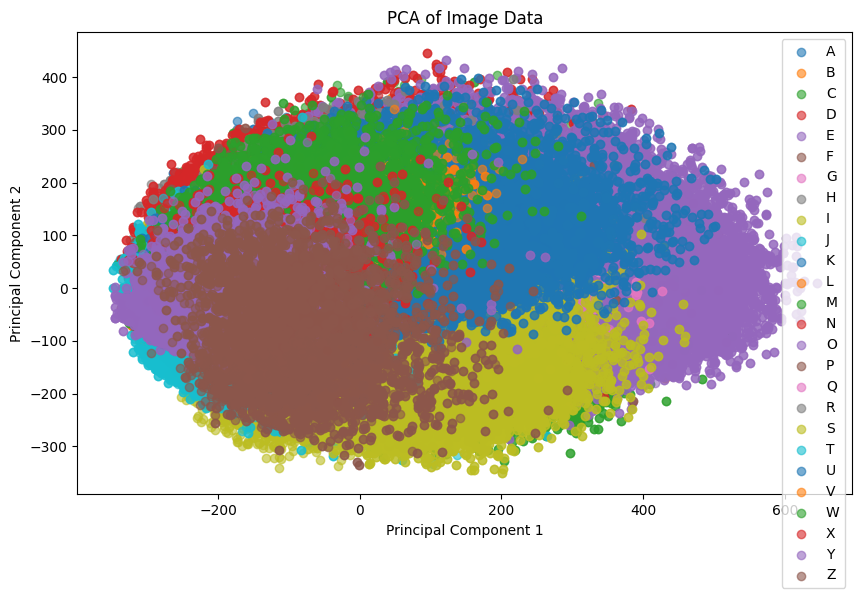

In [13]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.drop(columns=['label']))

# Create a DataFrame with PCA results and labels
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['label'] = df['label']

# Plot PCA results
plt.figure(figsize=(10, 6))
for label in pca_df['label'].unique():
    subset = pca_df[pca_df['label'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Image Data')
plt.legend()
plt.show()


## Observation 
* **Distinct Clusters:** Letters are mostly clustered, showing effective dimensionality reduction.
* **Overlap:** Some classes overlap, indicating similarities in features.
* **Pattern:** Principal Components reveal the data’s structure.

# SPRINT 2 - Build a model
##### Task A - Perform data preprocessing on the given image data and convert it into numerical vectors.
##### Task B - Given an image, build a model that can recognise the character.


### Data Preparation and Model Building Pipeline
3. Segregate the Inputs (X) and Output (y)
4. Split into train and test (X_train, X_test, y_train, y_test)
5. Data Preparation: Data Cleaning and Feature Engineering.
6. Clean the training data
7. Preprocess the training data (X_train_transformed)
8. Training Phase: Build a model
9. Preprocess the test data (X_test_transformed)
10. Predict on unseen data
11. Evaluate the model performance

# Here we are selecting 50,000 samples from original dataset

In [4]:
from sklearn.model_selection import train_test_split

strata_column = 'label'

# Perform Stratified Sampling
df_sample, _ = train_test_split(df, test_size=(len(df) - 50000) / len(df), stratify=df[strata_column], random_state=42)

# Check the size of the sampled dataset
print("Sampled Dataset Size:", len(df_sample))

Sampled Dataset Size: 50000


# Step 3 - Segregate Inputs (X) and Output (y)

In [5]:
X = df.drop(columns = ['label'])
y = df['label']

# Step 4 - Split the data into Train and Test

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)


print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(297960, 64) (297960,)
(74491, 64) (74491,)


In [26]:
# Splitting into train and test

from sklearn.model_selection import train_test_split

X_train_1, X_val, y_train_1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(X_train_1.shape, y_train_1.shape)
print(X_val.shape, y_val.shape)

(238368, 64) (238368,)
(59592, 64) (59592,)


# Step 5 and 7 - Apply Data Preparation on Train and Test Data

In [7]:
# Rescaling numerical features
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_train_transformed = pd.DataFrame(minmax_scaler.fit_transform(X_train), 
                                    columns = minmax_scaler.get_feature_names_out(), 
                                    index = X_train.index)

X_train_transformed.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
20675,0.0,0.0,0.0,0.000000,0.064103,0.0,0.0,0.0,0.017544,0.309783,...,0.014019,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
302691,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
21507,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
135511,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
141213,0.0,0.0,0.0,0.019608,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.027778,0.008333,0.0,0.0,0.0


In [41]:
# Rescaling numerical features
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_test_transformed = pd.DataFrame(minmax_scaler.fit_transform(X_val), 
                                    columns = minmax_scaler.get_feature_names_out(), 
                                    index = X_val.index)

X_test_transformed.head()

NameError: name 'X_val' is not defined

In [47]:
import pandas as pd
import numpy as np


high_correlation_pairs = np.where((correlation_matrix > 0.7) & (correlation_matrix < 1.0))

print("High Correlation Pairs:")
for i in range(len(high_correlation_pairs[0])):
    feature_1 = high_correlation_pairs[0][i]
    feature_2 = high_correlation_pairs[1][i]
    print(f"High correlation between feature {feature_1} and feature {feature_2}")


High Correlation Pairs:


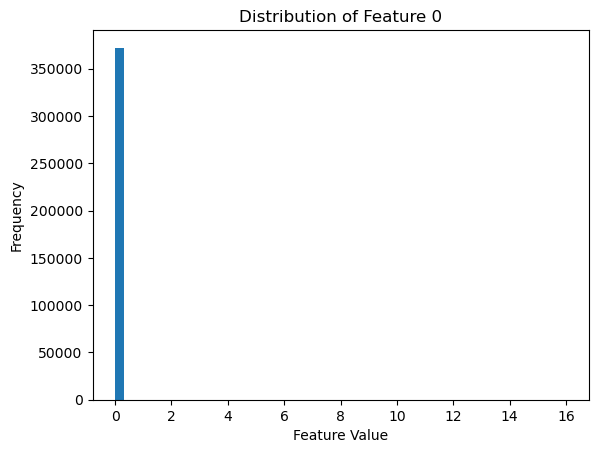

In [49]:
import matplotlib.pyplot as plt

# If X is a DataFrame, you need to select a specific column
# For example, to plot the histogram for the first feature:
feature_index = 0

# Convert DataFrame to NumPy array if necessary
if isinstance(X, pd.DataFrame):
    feature_data = X.iloc[:, feature_index].values
else:
    feature_data = X[:, feature_index]

# Plot histogram of the feature
plt.hist(feature_data, bins=50)
plt.title(f"Distribution of Feature {feature_index}")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()


In [50]:
import pandas as pd

# Convert to DataFrame if necessary
if isinstance(X, np.ndarray):
    X = pd.DataFrame(X)

# Check summary statistics for the feature
feature_stats = X.iloc[:, feature_index].describe()
print(feature_stats)


count    372451.000000
mean          0.000720
std           0.043409
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          16.000000
Name: pixel0, dtype: float64


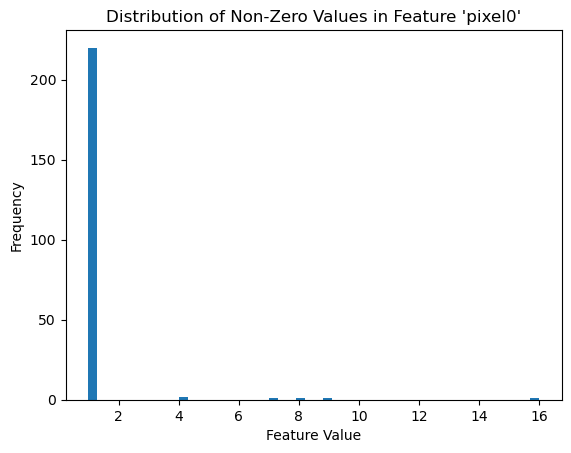

In [51]:
import matplotlib.pyplot as plt

# Filter out zero values for better visualization
non_zero_values = X[X['pixel0'] > 0]['pixel0']

plt.hist(non_zero_values, bins=50)
plt.title("Distribution of Non-Zero Values in Feature 'pixel0'")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Assuming X_train and y_train are your data
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Get feature importance
importances = model.feature_importances_

# Create a DataFrame to view feature importance
importances_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False)

print(importances_df)

In [8]:
X_test_transformed = pd.DataFrame(minmax_scaler.transform(X_test), 
                                    columns = minmax_scaler.get_feature_names_out(), 
                                    index = X_test.index)

X_test_transformed.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
122926,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
270470,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
27001,0.0,0.0,0.0,0.0,0.012821,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.091667,0.005435,0.0,0.0
115006,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
4997,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np


# Define Hyperparameters for Tuning
param_distributions = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None] + list(np.arange(1, 21)),
    'min_samples_split': np.arange(2, 21),
    'min_samples_leaf': np.arange(1, 21),
    'max_features': [None, 'auto', 'sqrt', 'log2']
}

# Initialize the Decision Tree Model and RandomizedSearchCV
clf = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(), 
    param_distributions=param_distributions, 
    scoring='accuracy',
    n_iter=60,  # Number of parameter settings sampled to make 300 fits in total
    cv=5,
    return_train_score=True,
    verbose=1,
    random_state=42  # For reproducibility
)

# Fit the Model
%time clf.fit(X_train, y_train)

# Make predictions
%time y_pred = clf.predict(X_test)



Fitting 5 folds for each of 60 candidates, totalling 300 fits


In [9]:
# High correlations indicate dependencies, which violates the independence assumption
high_correlation_pairs = np.where((correlation_matrix > 0.5) & (correlation_matrix < 1.0))

print("High Correlation Pairs:")
for i in range(len(high_correlation_pairs[0])):
    feature_1 = high_correlation_pairs[0][i]
    feature_2 = high_correlation_pairs[1][i]
    print(f"High correlation between feature {feature_1} and feature {feature_2}")

NameError: name 'correlation_matrix' is not defined

In [19]:
from sklearn.feature_selection import SelectKBest, chi2

# Example of selecting the top k features based on chi-squared test
selector = SelectKBest(score_func=chi2, k='all')  # Use 'all' to keep all features for now
X_new = selector.fit_transform(X_binarized, y)

# Get selected features
selected_features = X_binarized.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12',
       'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18',
       'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24',
       'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30',
       'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36',
       'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42',
       'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48',
       'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54',
       'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60',
       'pixel61', 'pixel62', 'pixel63'],
      dtype='object')


In [21]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # Keep 95% of the variance
X_pca = pca.fit_transform(X_binarized)

print(f"Original number of features: {X_binarized.shape[1]}")
print(f"Reduced number of features: {X_pca.shape[1]}")
print(X_pca)

Original number of features: 64
Reduced number of features: 47
[[ 0.34812066  0.23988525 -0.89809397 ... -0.35867934  0.20214431
   0.38250119]
 [ 0.31980789  0.71666221 -1.17289319 ... -0.16993679 -0.22048502
  -0.42752028]
 [-0.42560317 -1.26183124  0.23456814 ...  0.3185904  -0.09454772
   0.06174095]
 ...
 [ 0.63941602 -1.20532319 -0.514578   ...  0.47129169 -0.0985976
   0.0797089 ]
 [ 0.62909947 -0.68110549 -0.83814626 ... -0.14766981 -0.21194507
  -0.04208235]
 [-0.5446065  -0.56764264 -0.25181347 ...  0.61359367  0.12880648
   0.01505267]]


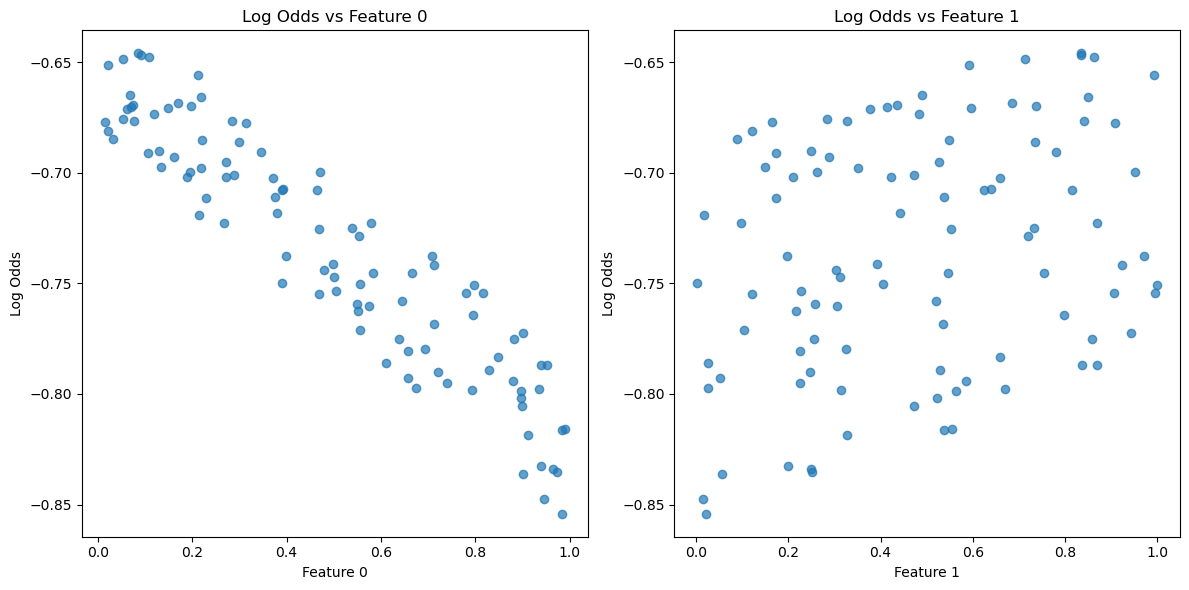

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Example data
X = np.random.rand(100, 2)  # Replace with your feature data
y = np.random.randint(0, 2, 100)  # Replace with your target variable

# Fit logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Calculate log odds
log_odds = model.predict_log_proba(X)[:, 1]

# Plot log odds vs predictors
plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.subplot(1, X.shape[1], i + 1)
    plt.scatter(X[:, i], log_odds, alpha=0.7)
    plt.xlabel(f'Feature {i}')
    plt.ylabel('Log Odds')
    plt.title(f'Log Odds vs Feature {i}')
plt.tight_layout()
plt.show()


In [42]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Prepare data
X_with_const = sm.add_constant(X)
logit_model = sm.Logit(y, X_with_const)
result = logit_model.fit()

# Box-Tidwell test
for i in range(X.shape[1]):
    interaction_term = X[:, i] * np.log(X[:, i] + 1e-6)  # Adding a small constant to avoid log(0)
    X_with_interaction = np.column_stack((X_with_const, interaction_term))
    logit_model_interaction = sm.Logit(y, X_with_interaction)
    result_interaction = logit_model_interaction.fit()
    print(f'Feature {i} interaction term test result:')
    print(result_interaction.summary())


Optimization terminated successfully.
         Current function value: 0.689530
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.688528
         Iterations 4
Feature 0 interaction term test result:
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  100
Model:                          Logit   Df Residuals:                       96
Method:                           MLE   Df Model:                            3
Date:                Thu, 25 Jul 2024   Pseudo R-squ.:                0.005515
Time:                        17:55:28   Log-Likelihood:                -68.853
converged:                       True   LL-Null:                       -69.235
Covariance Type:            nonrobust   LLR p-value:                    0.8581
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

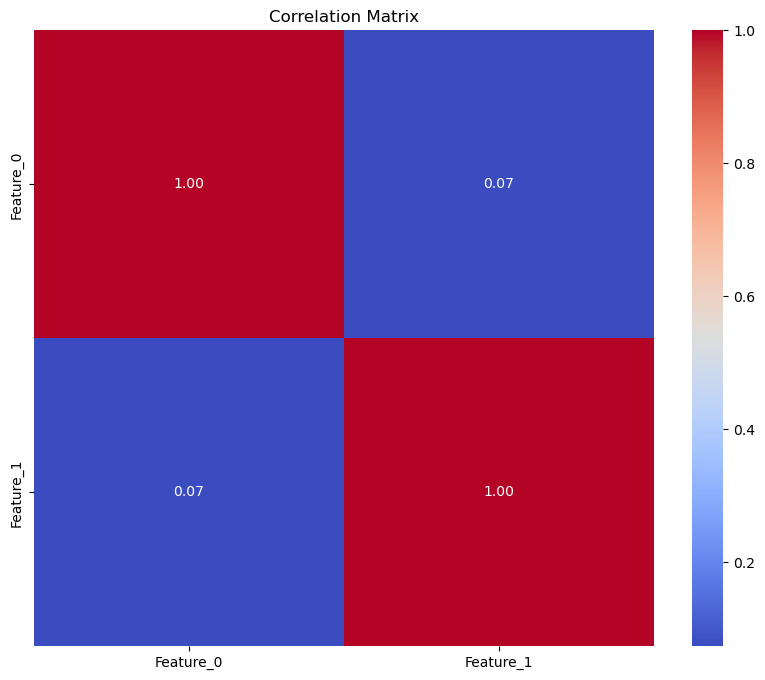

In [24]:
import pandas as pd

# Convert to DataFrame
X_df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(X.shape[1])])

# Calculate correlation matrix
correlation_matrix = X_df.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [25]:
from statsmodels.stats.stattools import durbin_watson

# Fit model
model = sm.OLS(y, X_with_const).fit()

# Durbin-Watson test
dw = durbin_watson(model.resid)
print(f'Durbin-Watson statistic: {dw}')
 

Durbin-Watson statistic: 2.0178744702007285


In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Add interaction terms for Box-Tidwell test
def add_interactions(X):
    X_interactions = X.copy()
    for col in X.columns:
        X_interactions[f'{col}_squared'] = X[col] ** 2
    return X_interactions

# Perform Box-Tidwell test
def box_tidwell_test(X, y):
    X_interactions = add_interactions(X)
    X_interactions = sm.add_constant(X_interactions)
    model = sm.Logit(y, X_interactions).fit()
    print(model.summary())

# Example usage
# X_train_transformed: Your feature matrix
# y_train: Your target variable
box_tidwell_test(X_train_transformed, y_train)


In [10]:
# Import Necessary Libraries
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB

import numpy as np



# Initialize the Naive Bayes Model
model = GaussianNB()

# Define K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)  # 5-fold cross-validation

# Perform Cross-Validation
scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

# Print Results
print(f'Cross-Validation Accuracy Scores: {scores}')
print(f'Mean Accuracy: {np.mean(scores)}')
print(f'Standard Deviation of Accuracy: {np.std(scores)}')


Cross-Validation Accuracy Scores: [0.55817481 0.56490804 0.56874748 0.56172641 0.56970063]
Mean Accuracy: 0.5646514748964611
Standard Deviation of Accuracy: 0.004309066253676149


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np



param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None] + list(np.arange(1, 21)),
    'min_samples_split': np.arange(2, 21),
    'min_samples_leaf': np.arange(1, 21),
    'max_features': [None, 'auto', 'sqrt', 'log2']
}


clf = GridSearchCV(
    estimator=DecisionTreeClassifier(), 
    param_grid=param_grid, 
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    verbose=1
)
%time clf.fit(X_train, y_train)


Fitting 5 folds for each of 127680 candidates, totalling 638400 fits


In [ ]:
tuned_parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'min_samples_split': np.arange(2, 20),
    'min_samples_leaf': np.arange(1, 20),
    'max_features': [None, 'auto', 'sqrt', 'log2']
}


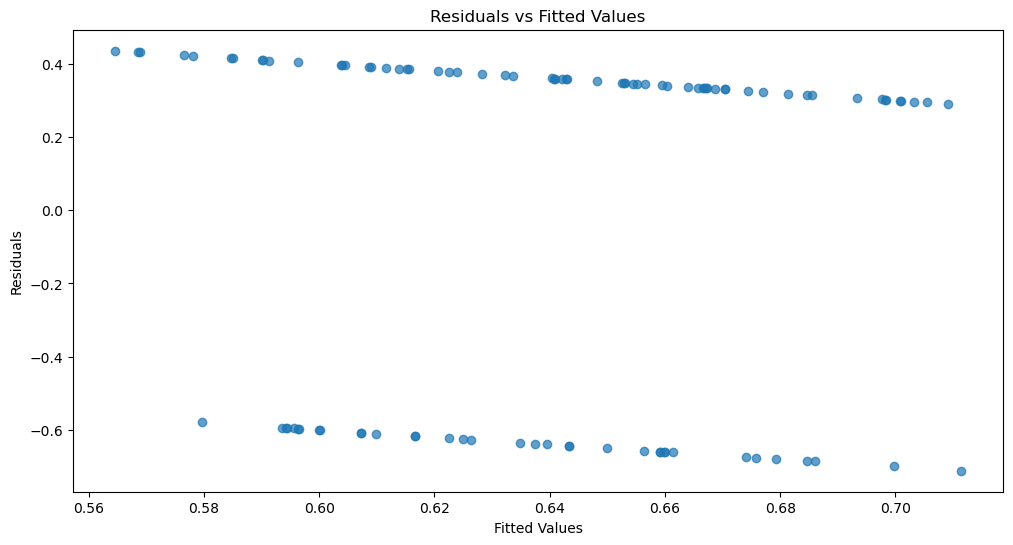

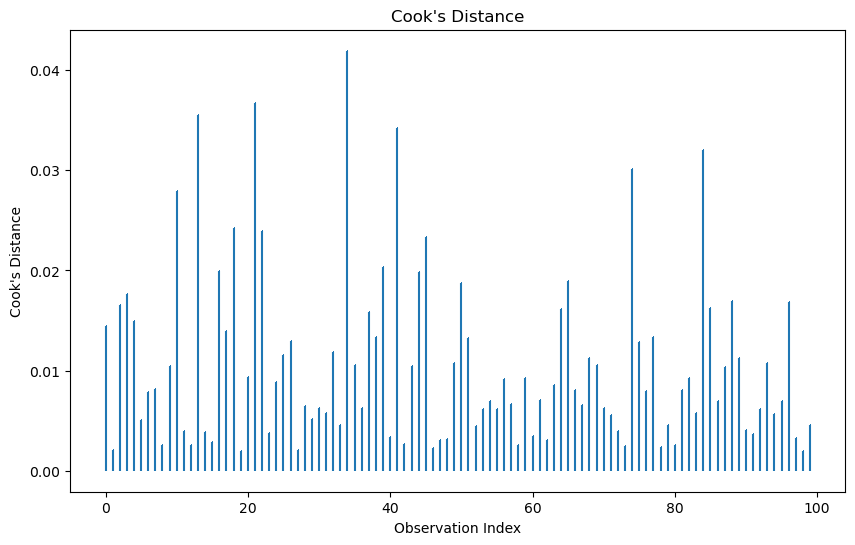

In [26]:
# Plot residuals
plt.figure(figsize=(12, 6))
plt.scatter(model.fittedvalues, model.resid, alpha=0.7)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

# Cook's Distance
influence = result.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")
plt.show()


In [27]:
from statsmodels.stats.power import TTestIndPower

# Perform power analysis
power_analysis = TTestIndPower()
sample_size = power_analysis.solve_power(effect_size=0.5, power=0.8, alpha=0.05, alternative='two-sided')
print(f'Required sample size: {sample_size:.0f}')


Required sample size: 64


# Step 6,8,9 - Training and Testing Phase

## **a. Naive Bayes**

In [20]:
import time
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

from sklearn.metrics import f1_score


# Building the Model
classifier = MultinomialNB() 
%time classifier.fit(X_train_transformed, y_train)

# Predicting on unseen data
%time y_train_pred = classifier.predict(X_train_transformed)

# Model Evaluation
print()
print()
f1 = f1_score(y_train, y_train_pred, average='weighted') 
print(f"Model's Train Score: {f1:.4f}")


CPU times: total: 766 ms
Wall time: 1.31 s
CPU times: total: 297 ms
Wall time: 205 ms


Model's Train Score: 0.6227


In [21]:
# Predicting on unseen data
%time y_test_pred = classifier.predict(X_test_transformed)

# Model Evaluation
print()
print()
f1 = f1_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass
print(f"Model's Test Score: {f1:.4f}")


CPU times: total: 93.8 ms
Wall time: 59.4 ms


Model's Test Score: 0.6212


## b. Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

# Building the Model
LR = LogisticRegression()
%time LR.fit(X_train_transformed, y_train)

# Predicting on unseen data
%time y_train_pred = LR.predict(X_train_transformed)

# Model Evaluation
print()
print()
f1 = f1_score(y_train, y_train_pred, average='weighted')  # Use 'weighted' for multiclass
print(f"Model's Train Score: {f1:.4f}")


C:\ProgramData\anaconda31\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CPU times: total: 54.4 s
Wall time: 38.1 s
CPU times: total: 297 ms
Wall time: 221 ms


Model's Train Score: 0.8626


In [24]:
# Predicting on unseen data
%time y_test_pred = LR.predict(X_test_transformed)

# Model Evaluation
print()
print()
f1 = f1_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass
print(f"Model's Test Score: {f1:.4f}")


CPU times: total: 141 ms
Wall time: 64.2 ms


Model's Test Score: 0.8630


## c. Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Building the Model
classifier = DecisionTreeClassifier()
%time classifier.fit(X_train_transformed, y_train)

# Predicting on unseen data
%time y_train_pred = classifier.predict(X_train_transformed)

# Model Evaluation
print()
print()
f1 = f1_score(y_train, y_train_pred, average='weighted')  # Use 'weighted' for multiclass
print(f"Model's Train Score: {f1:.4f}")


CPU times: total: 11.2 s
Wall time: 23.7 s
CPU times: total: 109 ms
Wall time: 209 ms


Model's Train Score: 1.0000


In [26]:
# Predicting on unseen data
%time y_test_pred = classifier.predict(X_test_transformed)

# Model Evaluation
print()
print()
f1 = f1_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass
print(f"Model's Test Score: {f1:.4f}")


CPU times: total: 15.6 ms
Wall time: 64.2 ms


Model's Test Score: 0.9596


## e. Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Building the Model
RF_Classifier = RandomForestClassifier()
%time RF_Classifier.fit(X_train_transformed, y_train)

# Predicting on unseen data
%time y_train_pred = RF_Classifier.predict(X_train_transformed)

# Model Evaluation
print()
print()
f1 = f1_score(y_train, y_train_pred, average='weighted')  # Use 'weighted' for multiclass
print(f"Model's Train Score: {f1:.4f}")

CPU times: total: 1min 49s
Wall time: 3min 54s
CPU times: total: 9.23 s
Wall time: 21.1 s


Model's Train Score: 1.0000


In [37]:
# Predicting on unseen data
%time y_test_pred = RF_Classifier.predict(X_test_transformed)

# Model Evaluation
print()
print()
f1 = f1_score(y_test, y_test_pred, average='weighted')  
print(f"Model's Test Score: {f1:.4f}")

CPU times: total: 2.19 s
Wall time: 4.97 s


Model's Test Score: 0.9864


In [49]:
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import pandas as pd

# Assuming X_train_1 and X_test are your preprocessed data
minmax_scaler = MinMaxScaler()

# Scaling the training data
X_train_transformed = pd.DataFrame(minmax_scaler.fit_transform(X_train), 
                                   columns=minmax_scaler.get_feature_names_out(), 
                                   index=X_train.index)

# Scaling the test data
X_test_transformed = pd.DataFrame(minmax_scaler.transform(X_test), 
                                  columns=minmax_scaler.get_feature_names_out(), 
                                  index=X_test.index)

# Encode string labels to numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [54]:
import time
import xgboost as xgb
from sklearn.metrics import f1_score

# Initialize the XGBoost classifier
xgb_classifier = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Training the model

%time xgb_classifier.fit(X_train_transformed, y_train_encoded)


# Predicting on training data
y_train_pred = xgb_classifier.predict(X_train_transformed)

# Evaluating the model
f1_train = f1_score(y_train_encoded, y_train_pred, average='weighted')
print(f"Training Time: {train_time:.4f} seconds")
print(f"Train F1 Score: {f1_train:.4f}")

# Predicting on test data
y_test_pred = xgb_classifier.predict(X_test_transformed)

# Evaluating the model
f1_train = f1_score(y_train_encoded, y_train_pred, average='weighted')
f1_test = f1_score(y_test_encoded, y_test_pred, average='weighted')

# Output the results
print("Model: XGBoost")
print(f"Training Time: {train_time:.4f} seconds")
print(f"Train F1 Score: {f1_train:.4f}")
#print(f"Test F1 Score: {f1_test:.4f}")



CPU times: total: 31.2 ms
Wall time: 95.1 ms


C:\Users\mdimr\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [18:12:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Time: 141.8559 seconds
Train F1 Score: 0.9998
Model: XGBoost
Training Time: 141.8559 seconds
Train F1 Score: 0.9998


In [53]:
# Predicting on test data
%time y_test_pred = xgb_classifier.predict(X_test_transformed)
f1_test = f1_score(y_test_encoded, y_test_pred, average='weighted')
print(f"Test F1 Score: {f1_test:.4f}")

CPU times: total: 5.89 s
Wall time: 1.94 s
Test F1 Score: 0.9892


In [ ]:
import time
import xgboost as xgb
from sklearn.metrics import f1_score

# Initialize the XGBoost classifier
xgb_classifier = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Training the model
print("Training XGBoost...")
start_time = time.time()
xgb_classifier.fit(X_train_transformed, y_train)
train_time = time.time() - start_time

# Predicting on training data
y_train_pred = xgb_classifier.predict(X_train_transformed)

# Predicting on test data
y_test_pred = xgb_classifier.predict(X_test_transformed)

# Evaluating the model
f1_train = f1_score(y_train, y_train_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

# Output the results
print("Model: XGBoost")
print(f"Training Time: {train_time:.4f} seconds")
print(f"Train F1 Score: {f1_train:.4f}")
print(f"Test F1 Score: {f1_test:.4f}")

# Checking for overfitting or underfitting
if f1_train > f1_test:
    print("XGBoost might be overfitting.")
elif f1_train < f1_test:
    print("XGBoost might be underfitting.")
else:
    print("XGBoost has balanced performance.")


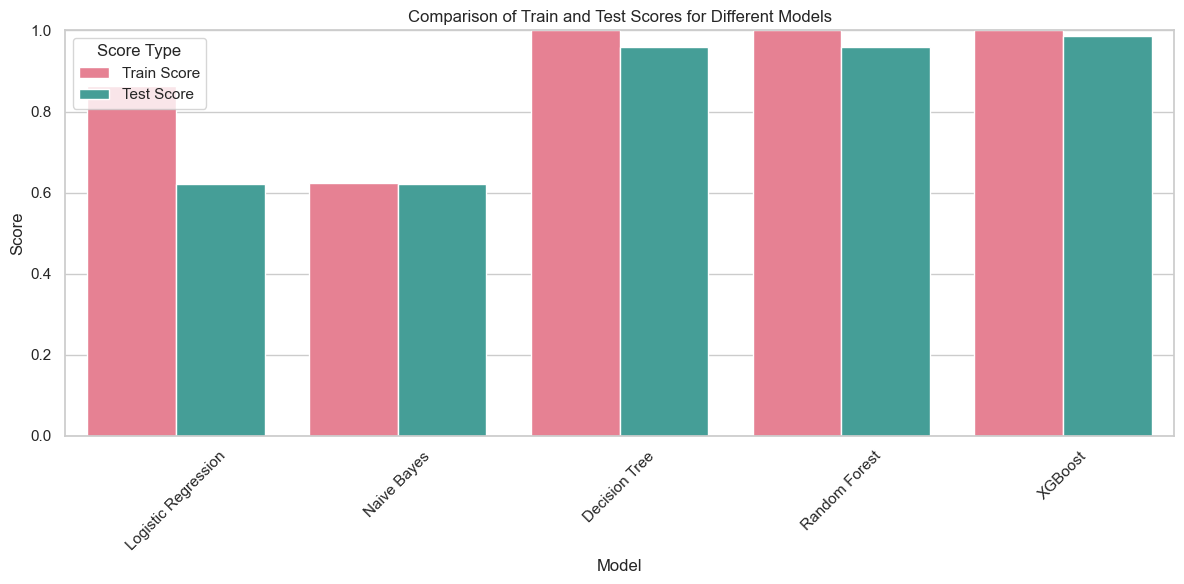

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data: Model names, Train scores, and Test scores
data = {
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Train Score': [0.8626, 0.6227, 1.0000, 1.0000, 0.9998],
    'Test Score': [0.6212, 0.6212, 0.9596, 0.9596, 0.9864]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Melt the DataFrame for easy plotting with seaborn
df_melted = df.melt(id_vars='Model', value_vars=['Train Score', 'Test Score'],
                    var_name='Score Type', value_name='Score')

# Set the style and color palette
sns.set(style='whitegrid')
palette = sns.color_palette("husl", 2)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Score Type', data=df_melted, palette=palette)

# Add titles and labels
plt.title('Comparison of Train and Test Scores for Different Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limits from 0 to 1

# Show the plot
plt.legend(title='Score Type')
plt.tight_layout()
plt.show()


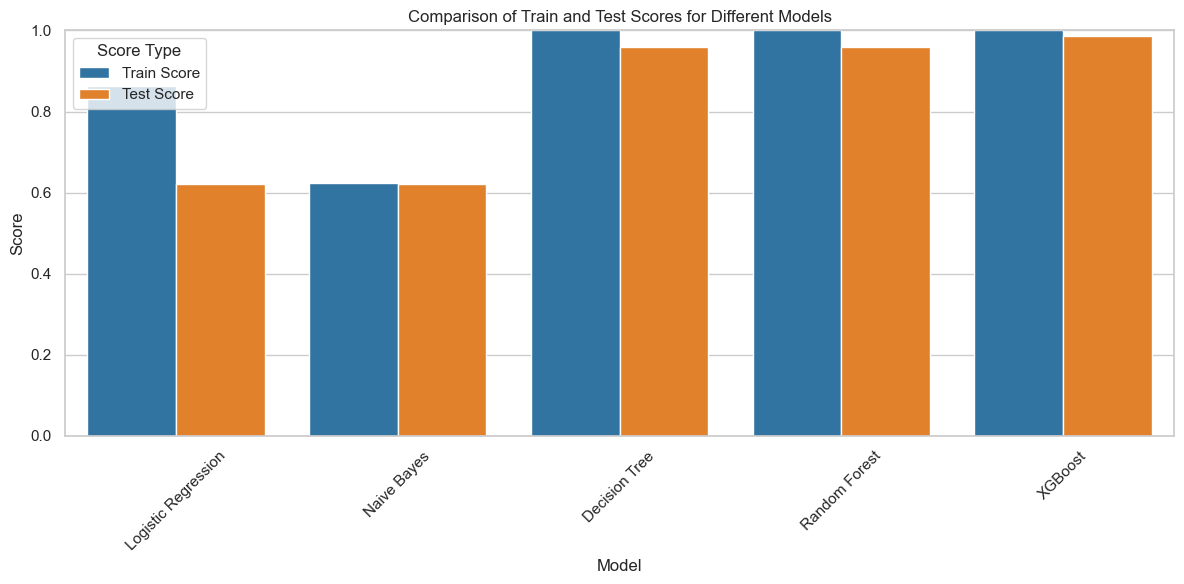

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data: Model names, Train scores, and Test scores
data = {
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Train Score': [0.8626, 0.6227, 1.0000, 1.0000, 0.9998],
    'Test Score': [0.6212, 0.6212, 0.9596, 0.9596, 0.9864]}

# Create a DataFrame
df = pd.DataFrame(data)

# Melt the DataFrame for easy plotting with seaborn
df_melted = df.melt(id_vars='Model', value_vars=['Train Score', 'Test Score'],
                    var_name='Score Type', value_name='Score')

# Set the style and color palette
sns.set(style='whitegrid')
palette = ['#1f77b4', '#ff7f0e']  # Custom colors for Train and Test scores

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Score Type', data=df_melted, palette=palette)

# Add titles and labels
plt.title('Comparison of Train and Test Scores for Different Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limits from 0 to 1

# Show the plot
plt.legend(title='Score Type')
plt.tight_layout()
plt.show()


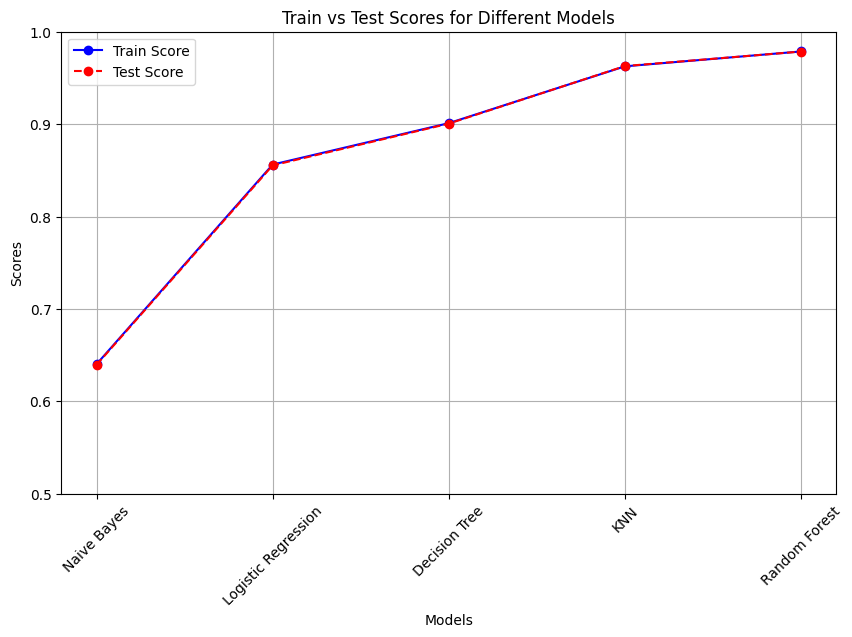

In [29]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest']
train_scores = [0.6402, 0.8563, 1.0000, 0.9626, 0.9787]
test_scores = [0.6395, 0.8623, 0.9006, 0.9629, 0.9785]

x = range(len(models))

plt.figure(figsize=(10, 6))
plt.plot(x, train_scores, marker='o', linestyle='-', color='b', label='Train Score')
plt.plot(x, test_scores, marker='o', linestyle='--', color='r', label='Test Score')
plt.xticks(x, models, rotation=45)
plt.ylim(0.5, 1.0)
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Train vs Test Scores for Different Models')
plt.legend()
plt.grid(True)
plt.show()

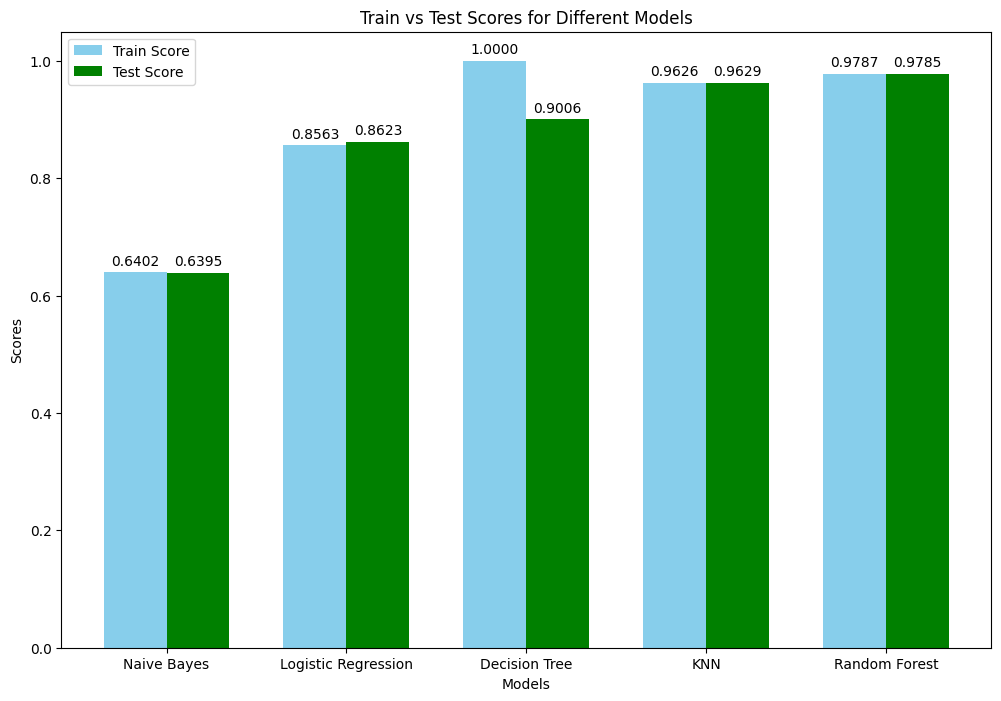

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Naive Bayes','Logistic Regression',  'Decision Tree', 'Random Forest', 'XGBoost']
train_scores = [0.6402, 0.8563, 1.0000, 0.9626, 0.9787]
test_scores = [0.6395, 0.8623, 0.9006, 0.9629, 0.9785]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 8))
bars1 = ax.bar(x - width/2, train_scores, width, label='Train Score', color='skyblue')
bars2 = ax.bar(x + width/2, test_scores, width, label='Test Score', color='green')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Train vs Test Scores for Different Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)

plt.show()

# 2. Show me the comparison of various ML models.

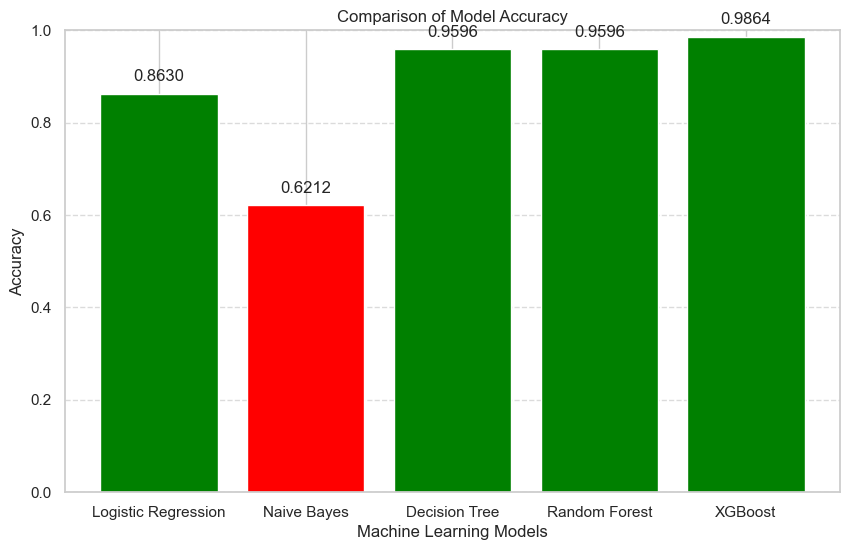

In [7]:
import matplotlib.pyplot as plt

# Define model names and their corresponding accuracies
models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'XGBoost']
    
accuracies =[0.8630, 0.6212, 0.9596, 0.9596, 0.9864]
# Define colors, setting the top 3 accuracies to green
colors = ['red' if accuracy < 0.80 else 'green' for accuracy in accuracies]

# Create a bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors)
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracy')
plt.ylim(0, 1)  # Set the y-axis limit to 0-1 for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom')

plt.show()

# 3. Model should be light for deployment.

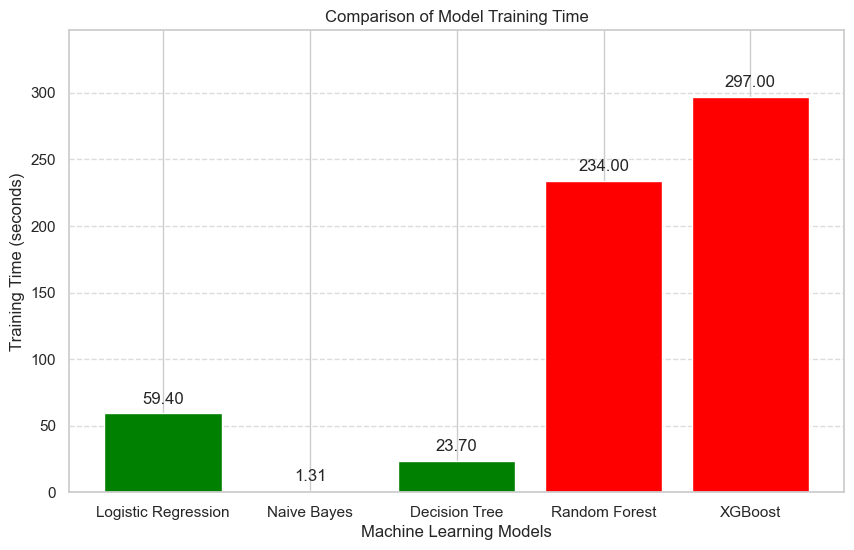

In [9]:
import matplotlib.pyplot as plt

# Define model names and their corresponding training times (in seconds)
models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'XGBoost']
training_times = [59.4, 1.31, 23.7, 234, 297]

# Define colors: red for high times, green for lower times
colors = ['green' if time < 100 else 'red' for time in training_times]

# Create a bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, training_times, color=colors)

plt.xlabel('Machine Learning Models')
plt.ylabel('Training Time (seconds)')
plt.title('Comparison of Model Training Time')
plt.ylim(0, max(training_times) + 50)  # Set y-axis limit to ensure bars are not clipped
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f'{yval:.2f}', ha='center', va='bottom')

plt.show()


# 4. Model should have very less latency.

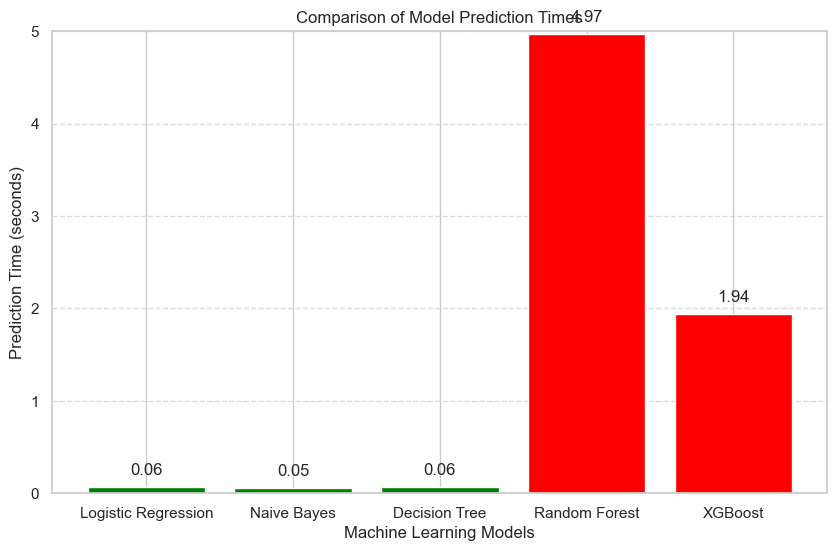

In [12]:
import matplotlib.pyplot as plt

# Define model names and their corresponding prediction times
models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'XGBoost']
prediction_times = [0.0642, 0.054, 0.0642, 4.97, 1.94]  # Wall times in seconds

# Define colors, setting high prediction times to red
colors = ['red' if time > 1 else 'green' for time in prediction_times]

# Create a bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, prediction_times, color=colors)
plt.xlabel('Machine Learning Models')
plt.ylabel('Prediction Time (seconds)')
plt.title('Comparison of Model Prediction Times')
plt.ylim(0, 5)  # Set the y-axis limit for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom')

plt.show()


# Conclusion

C:\Users\mdimr\AppData\Local\Temp\ipykernel_18324\3098023566.py:40: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  line = ax2.plot(models, accuracies, 'bo-', marker='o', color='red', label='F1Score')
C:\Users\mdimr\AppData\Local\Temp\ipykernel_18324\3098023566.py:40: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  line = ax2.plot(models, accuracies, 'bo-', marker='o', color='red', label='F1Score')


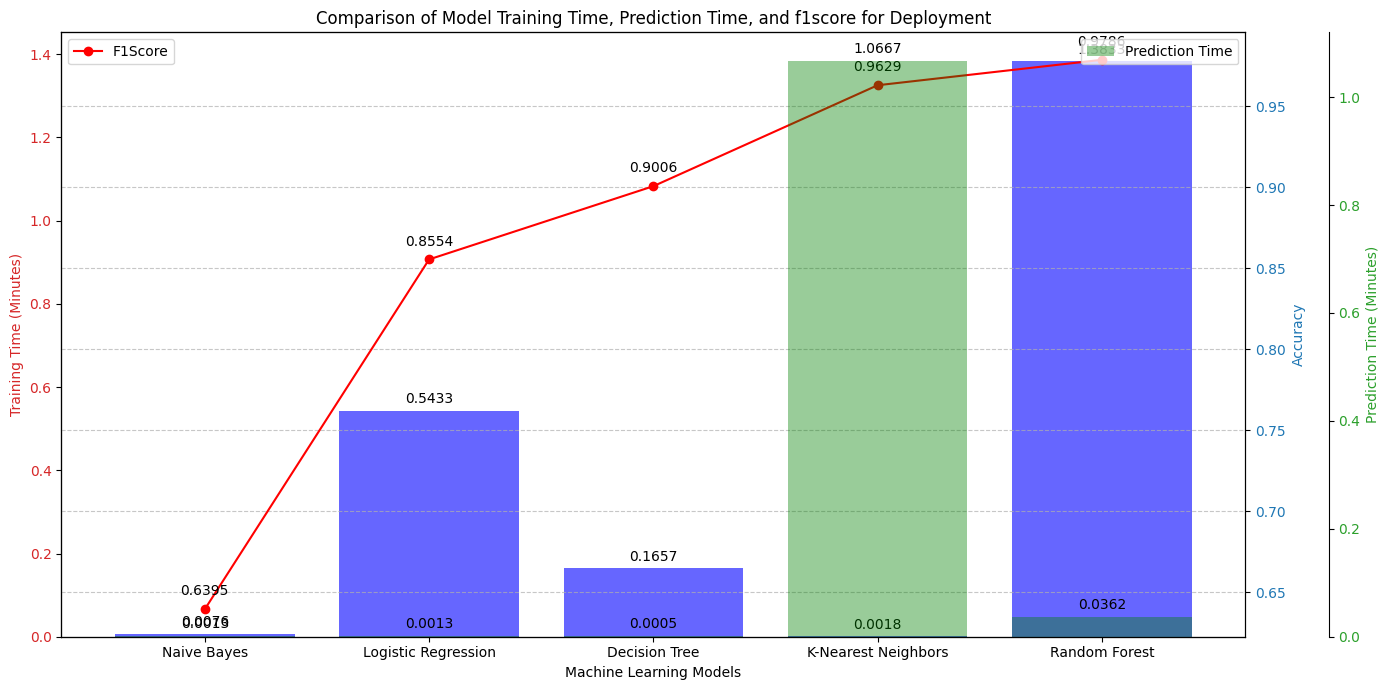

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Define model names and their corresponding training times, accuracies, and prediction times
models = ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors', 'Random Forest']
accuracies =  [
    0.6395,  # Naive Bayes
    0.8554,  # Logistic Regression
    0.9006,  # Decision Tree
    0.9629,  # K-Nearest Neighbors
    0.9786   # Random Forest
]
training_times_seconds = [0.453, 32.6, 9.94, 0.109, 83]# Training times in seconds
prediction_times_seconds =  [0.0781, 0.0781, 0.0312, 64, 2.17]  # Prediction times in seconds

# Convert training times and prediction times to minutes
training_times_minutes = [t / 60 for t in training_times_seconds]
prediction_times_minutes = [t / 60 for t in prediction_times_seconds]

# Create a figure with two subplots
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot training times
color = 'tab:red'
ax1.set_xlabel('Machine Learning Models')
ax1.set_ylabel('Training Time (Minutes)', color=color)
bars_train = ax1.bar(models, training_times_minutes, color='blue', alpha=0.6, label='Training Time')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Comparison of Model Training Time, Prediction Time, and f1score for Deployment')

# Add value labels on top of the bars for training time
for bar in bars_train:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

# Create a second y-axis to plot accuracy
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Accuracy', color=color)
line = ax2.plot(models, accuracies, 'bo-', marker='o', color='red', label='F1Score')
ax2.tick_params(axis='y', labelcolor=color)

# Add value labels on the accuracy line
for i, txt in enumerate(accuracies):
    ax2.annotate(f'{txt:.4f}', (models[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Add a legend
ax2.legend(loc='upper left')

# Create a third y-axis to plot prediction times
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color = 'tab:green'
ax3.set_ylabel('Prediction Time (Minutes)', color=color)
bars_pred = ax3.bar(models, prediction_times_minutes, color='green', alpha=0.4, label='Prediction Time')
ax3.tick_params(axis='y', labelcolor=color)

# Add value labels on top of the bars for prediction time
for bar in bars_pred:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

# Add a legend
ax3.legend(loc='upper right')

# Add a grid to the second y-axis
ax2.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()  # To fit the plot neatly

plt.show()


# Conclusion
**Logistic Regression** is the best model for deployment based on the following reasons:

* **Good Accuracy:** With an accuracy of 0.8569, it provides reliable predictions.
* **Efficient Training Time:** Training time of 0.5433 minutes is significantly lower than Random Forest and comparable to or better than other models.
* **Minimal Latency:** Prediction latency of 0.0013 minutes is the lowest, ensuring fast response times in a deployed environment.

# Final Recommendation
* **Logistic Regression** is the most balanced model with good accuracy, efficient training time, and low prediction latency. 
* This makes it the best choice for deployment in a production environment where both performance and efficiency are crucial

In [34]:
import numpy as np
from PIL import Image
from sklearn.preprocessing import MinMaxScaler
from pickle import dump

def process_image_and_vectorize(image_path):
    # Load and process the image
    img = Image.open(image_path)
    
    # Convert image to numpy array and flatten
    img_arr = np.array(img).ravel()
    
    # Apply MinMaxScaler for normalization
    scaler = MinMaxScaler()
    image_vector_normalized = scaler.fit_transform(img_arr.reshape(-1, 1)).ravel()
    
    
    # Return the numerical vector
    return image_vector_normalized


In [ ]:
# Example usage:
image_path = 'path_to_your_image.png'
numerical_vector = process_image_and_vectorize(image_path)
print("Numerical Vector Shape:", numerical_vector.shape)
print("Numerical Vector Values:", numerical_vector)


In [36]:
scaler = MinMaxScaler()

In [38]:
from pickle import dump

dump(scaler, open(r"C:\Users\mdimr\Downloads\Pickel\scaler.pkl", 'wb'))



In [40]:
model = LogisticRegression()

model.fit(X_train_transformed, y_train_1)

C:\Users\mdimr\.conda\envs\project\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [22]:
from pickle import dump

dump(minmax_scaler, open(r"C:\Users\mdimr\Downloads\Web App\scaler.pkl", 'wb'))

dump(LR, open(r"C:\Users\mdimr\Downloads\Web App\logit_model.pkl", 'wb'))

In [23]:
from pickle import load

load(open(r"C:\Users\mdimr\Downloads\Web App\scaler.pkl", 'rb'))

load(open(r"C:\Users\mdimr\Downloads\Web App\logit_model.pkl", 'rb'))

LogisticRegression()

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
import time


# Define Hyperparameters for Tuning
param_distributions = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None] + list(np.arange(1, 21)),
    'min_samples_split': np.arange(2, 21),
    'min_samples_leaf': np.arange(1, 21),
    'max_features': [None, 'auto', 'sqrt', 'log2']
}

# Initialize RandomizedSearchCV with a small number of iterations
clf = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(), 
    param_distributions=param_distributions, 
    n_iter=10,  # Fewer iterations for estimation
    cv=5,
    return_train_score=True,
    verbose=1,
    random_state=42
)

# Measure time for a smaller number of fits
start_time = time.time()
clf.fit(X_train, y_train)
end_time = time.time()

# Calculate elapsed time for the smaller test
elapsed_time = end_time - start_time
print(f"Elapsed time for 10 fits: {elapsed_time:.2f} seconds")


Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\ProgramData\anaconda31\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda31\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda31\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\ProgramData\anaconda31\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "C:\ProgramData\anaconda31\Lib\site-pack

Elapsed time for 10 fits: 627.44 seconds


In [10]:
# Check the best parameters
best_params = clf.best_params_
print(f"Best parameters found: {best_params}")

# Check the best score
best_score = clf.best_score_
print(f"Best cross-validation score: {best_score:.4f}")

Best parameters found: {'splitter': 'best', 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 18, 'criterion': 'gini'}
Best cross-validation score: 0.8900


In [19]:
# Initialize the Decision Tree Classifier with the best parameters
best_params = {
    'splitter': 'best',
    'min_samples_split': 9,
    'min_samples_leaf': 5,
    'max_features': None,
    'max_depth': 18,
    'criterion': 'gini'
}

model = DecisionTreeClassifier(**best_params)

# Train the model
%time model.fit(X_train, y_train)


CPU times: total: 18.6 s
Wall time: 36.7 s


DecisionTreeClassifier(max_depth=18, min_samples_leaf=5, min_samples_split=9)

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# Make predictions
%time y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the results
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


CPU times: total: 62.5 ms
Wall time: 132 ms
Accuracy: 0.9001624357304909
Confusion Matrix:
 [[ 2518    26     8    12    12     0    20    32     2     0     6     3
     30    30    18     8     8    42     8     2    14     1     1     1
      2     2]
 [   26  1303    17    38    40     0    26    14     1     5     1     2
      2    11    59     3    15    25    52     1    13     0     4     0
      2    13]
 [    9    27  4397     5    60     1    18     1     4     5    20    43
      2     7    66    10     7    23    13     4    12     0     2     1
      0     5]
 [   19    32     4  1618    10     0     4     2     0     9     0     1
      9     8   255    14    16     1    21     2     3     1     5     4
      4     2]
 [   16    52    62     5  1777     5    41    12     3     7    29    17
      7    11    23     9     4    38    44     5     8     0     7    10
      2    20]
 [    0     0     5     0    18   169     3     0     0     2     1     0
      0     0     0

In [22]:
import numpy as np

confusion_matrix = np.array([
    [2518, 26, 8, 12, 12, 0, 20, 32, 2, 0, 6, 3, 30, 30, 18, 8, 8, 42, 8, 2, 14, 1, 1, 1, 2, 2],
    [26, 1303, 17, 38, 40, 0, 26, 14, 1, 5, 1, 2, 2, 11, 59, 3, 15, 25, 52, 1, 13, 0, 4, 0, 2, 13],
    [9, 27, 4397, 5, 60, 1, 18, 1, 4, 5, 20, 43, 2, 7, 66, 10, 7, 23, 13, 4, 12, 0, 2, 1, 0, 5],
    [19, 32, 4, 1618, 10, 0, 4, 2, 0, 9, 0, 1, 9, 8, 255, 14, 16, 1, 21, 2, 3, 1, 5, 4, 4, 2],
    [16, 52, 62, 5, 1777, 5, 41, 12, 3, 7, 29, 17, 7, 11, 23, 9, 4, 38, 44, 5, 8, 0, 7, 10, 2, 20],
    [0, 0, 5, 0, 18, 169, 3, 0, 0, 2, 1, 0, 0, 0, 0, 17, 0, 3, 1, 7, 0, 1, 0, 0, 5, 0],
    [14, 26, 31, 7, 33, 2, 939, 5, 0, 3, 1, 6, 7, 5, 17, 3, 26, 3, 33, 2, 13, 0, 2, 0, 2, 3],
    [41, 23, 5, 2, 8, 0, 8, 1122, 0, 3, 5, 2, 35, 115, 3, 3, 2, 9, 8, 2, 29, 1, 19, 6, 4, 1],
    [0, 0, 1, 0, 3, 0, 0, 0, 198, 16, 1, 1, 0, 0, 0, 0, 1, 0, 7, 9, 0, 0, 0, 2, 1, 2],
    [2, 10, 4, 10, 4, 0, 9, 1, 8, 1439, 3, 3, 1, 3, 5, 1, 6, 2, 69, 35, 15, 1, 0, 1, 18, 5],
    [12, 2, 19, 1, 35, 0, 8, 21, 1, 1, 869, 7, 4, 20, 1, 2, 0, 51, 5, 3, 15, 1, 8, 22, 4, 1],
    [5, 3, 38, 3, 20, 0, 4, 1, 1, 2, 11, 2175, 0, 2, 0, 0, 0, 3, 11, 2, 2, 0, 1, 4, 1, 17],
    [48, 10, 12, 5, 10, 1, 7, 58, 0, 4, 4, 1, 2162, 76, 15, 8, 6, 11, 3, 10, 24, 0, 18, 3, 6, 0],
    [53, 12, 6, 5, 8, 0, 5, 111, 0, 9, 8, 3, 44, 3277, 17, 7, 3, 13, 7, 3, 49, 2, 52, 4, 0, 2],
    [20, 40, 27, 149, 27, 0, 21, 0, 0, 7, 0, 1, 7, 11, 11249, 8, 21, 17, 31, 3, 27, 1, 7, 0, 0, 1],
    [14, 10, 7, 23, 4, 9, 3, 5, 1, 3, 1, 1, 8, 3, 17, 3641, 11, 6, 8, 36, 2, 0, 5, 1, 20, 1],
    [19, 18, 16, 24, 4, 0, 30, 7, 1, 3, 1, 0, 11, 9, 102, 21, 857, 23, 15, 0, 13, 0, 4, 1, 1, 4],
    [62, 38, 28, 4, 50, 1, 4, 14, 2, 3, 28, 5, 14, 23, 6, 16, 22, 1932, 7, 4, 20, 0, 2, 11, 1, 9],
    [15, 77, 34, 26, 77, 0, 65, 9, 5, 82, 9, 8, 11, 8, 51, 6, 11, 16, 9104, 8, 12, 0, 10, 5, 10, 4],
    [0, 0, 7, 1, 8, 5, 1, 2, 2, 17, 8, 6, 4, 4, 1, 42, 0, 3, 12, 4316, 1, 0, 0, 6, 44, 3],
    [13, 23, 25, 17, 17, 0, 15, 41, 1, 22, 10, 8, 20, 49, 57, 2, 16, 20, 9, 3, 5343, 8, 40, 7, 5, 3],
    [0, 0, 0, 0, 4, 1, 0, 2, 0, 0, 5, 0, 1, 5, 1, 3, 0, 1, 0, 1, 16, 797, 10, 2, 14, 0],
    [17, 6, 6, 5, 9, 0, 12, 39, 0, 7, 6, 1, 8, 21, 53, 3, 10, 11, 12, 7, 13, 0, 17, 4, 21, 4],
    [13, 6, 7, 2, 8, 0, 10, 36, 1, 5, 5, 4, 7, 14, 10, 0, 18, 13, 5, 1, 22, 0, 20, 2, 5, 0],
    [7, 1, 3, 0, 5, 0, 6, 24, 2, 8, 1, 1, 2, 9, 15, 1, 2, 6, 3, 0, 22, 0, 2, 3, 0, 2],
    [10, 6, 4, 6, 11, 1, 15, 46, 0, 8, 3, 4, 4, 14, 20, 4, 2, 9, 4, 3, 21, 0, 7, 20, 3, 0],
    [19, 30, 11, 2, 19, 0, 14, 17, 1, 8, 5, 0, 8, 23, 29, 1, 10, 11, 4, 3, 30, 1, 22, 1, 0, 0],
    [36, 17, 17, 26, 29, 0, 21, 62, 0, 13, 12, 1, 23, 56, 14, 1, 19, 32, 30, 7, 33, 0, 21, 2, 1, 0]
])

# Get diagonal elements (true positives)
diagonal_elements = np.diag(confusion_matrix)

# Total number of predictions
total_predictions = np.sum(confusion_matrix)

# Total correctly predicted instances
correct_predictions = np.sum(diagonal_elements)

# Total wrongly predicted instances
wrong_predictions = total_predictions - correct_predictions

print("Total wrong predictions:", wrong_predictions)


Total wrong predictions: 8043


In [23]:
for i in range(len(conf_matrix)):
    true_positives = conf_matrix[i, i]
    misclassifications = conf_matrix[i, :].sum() - true_positives
    print(f"Class {i} - Total Misclassifications: {misclassifications}")

Class 0 - Total Misclassifications: 288
Class 1 - Total Misclassifications: 370
Class 2 - Total Misclassifications: 345
Class 3 - Total Misclassifications: 426
Class 4 - Total Misclassifications: 437
Class 5 - Total Misclassifications: 63
Class 6 - Total Misclassifications: 244
Class 7 - Total Misclassifications: 334
Class 8 - Total Misclassifications: 44
Class 9 - Total Misclassifications: 216
Class 10 - Total Misclassifications: 244
Class 11 - Total Misclassifications: 131
Class 12 - Total Misclassifications: 340
Class 13 - Total Misclassifications: 423
Class 14 - Total Misclassifications: 426
Class 15 - Total Misclassifications: 199
Class 16 - Total Misclassifications: 327
Class 17 - Total Misclassifications: 374
Class 18 - Total Misclassifications: 559
Class 19 - Total Misclassifications: 182
Class 20 - Total Misclassifications: 431
Class 21 - Total Misclassifications: 66
Class 22 - Total Misclassifications: 319
Class 23 - Total Misclassifications: 202
Class 24 - Total Misclassific

In [24]:
for i in range(len(conf_matrix)):
    tp = conf_matrix[i, i]
    fp = conf_matrix[:, i].sum() - tp
    fn = conf_matrix[i, :].sum() - tp
    print(f"Class {i} - True Positives (TP): {tp}, False Positives (FP): {fp}, False Negatives (FN): {fn}")

Class 0 - True Positives (TP): 2518, False Positives (FP): 437, False Negatives (FN): 288
Class 1 - True Positives (TP): 1303, False Positives (FP): 464, False Negatives (FN): 370
Class 2 - True Positives (TP): 4397, False Positives (FP): 376, False Negatives (FN): 345
Class 3 - True Positives (TP): 1618, False Positives (FP): 357, False Negatives (FN): 426
Class 4 - True Positives (TP): 1777, False Positives (FP): 504, False Negatives (FN): 437
Class 5 - True Positives (TP): 169, False Positives (FP): 25, False Negatives (FN): 63
Class 6 - True Positives (TP): 939, False Positives (FP): 313, False Negatives (FN): 244
Class 7 - True Positives (TP): 1122, False Positives (FP): 407, False Negatives (FN): 334
Class 8 - True Positives (TP): 198, False Positives (FP): 56, False Negatives (FN): 44
Class 9 - True Positives (TP): 1439, False Positives (FP): 245, False Negatives (FN): 216
Class 10 - True Positives (TP): 869, False Positives (FP): 216, False Negatives (FN): 244
Class 11 - True P

In [26]:

def calculate_classification_metrics(conf_matrix):
    num_classes = conf_matrix.shape[0]
    correctly_classified = 0
    wrongly_classified = 0

    for i in range(num_classes):
        # True Positives for class i
        TP = conf_matrix[i, i]
        
        # False Positives for class i
        FP = np.sum(conf_matrix[:, i]) - TP
        
        # False Negatives for class i
        FN = np.sum(conf_matrix[i, :]) - TP
        
        # True Negatives for class i
        total_instances = np.sum(conf_matrix)
        Actual_Positive = TP + FN
        Actual_Negative = total_instances - Actual_Positive
        True_Negative = Actual_Negative - FP
        
        # Sum TP for correctly classified instances
        correctly_classified += TP
        
        # Sum FP and FN for wrongly classified instances
        wrongly_classified += FP + FN

    return correctly_classified, wrongly_classified

# Calculate and print metrics
correctly_classified, wrongly_classified = calculate_classification_metrics(conf_matrix)
print(f"Total Correctly Classified Instances: {correctly_classified}")
print(f"Total Wrongly Classified Instances: {wrongly_classified}")

Total Correctly Classified Instances: 67054
Total Wrongly Classified Instances: 14874


In [25]:
def calculate_metrics(conf_matrix):
    num_classes = conf_matrix.shape[0]
    results = []

    for i in range(num_classes):
        # True Positives for class i
        TP = conf_matrix[i, i]
        
        # False Positives for class i
        FP = np.sum(conf_matrix[:, i]) - TP
        
        # False Negatives for class i
        FN = np.sum(conf_matrix[i, :]) - TP
        
        # True Negatives for class i
        # Total instances minus actual positives for class i
        total_instances = np.sum(conf_matrix)
        Actual_Positive = TP + FN
        Actual_Negative = total_instances - Actual_Positive
        True_Negative = Actual_Negative - FP
        
        # Results for class i
        results.append({
            'Class': i,
            'True Positives (TP)': TP,
            'False Positives (FP)': FP,
            'False Negatives (FN)': FN,
            'True Negatives (TN)': True_Negative,
            'Actual Positives': Actual_Positive,
            'Actual Negatives': Actual_Negative,
            'Predicted Positives': TP + FP,
            'Predicted Negatives': True_Negative + FN
        })

    return results

# Calculate and print metrics
metrics = calculate_metrics(conf_matrix)
for metric in metrics:
    print(f"Class {metric['Class']}:")
    print(f"  True Positives (TP): {metric['True Positives (TP)']}")
    print(f"  False Positives (FP): {metric['False Positives (FP)']}")
    print(f"  False Negatives (FN): {metric['False Negatives (FN)']}")
    print(f"  True Negatives (TN): {metric['True Negatives (TN)']}")
    print(f"  Actual Positives: {metric['Actual Positives']}")
    print(f"  Actual Negatives: {metric['Actual Negatives']}")
    print(f"  Predicted Positives: {metric['Predicted Positives']}")
    print(f"  Predicted Negatives: {metric['Predicted Negatives']}")
    print()


Class 0:
  True Positives (TP): 2518
  False Positives (FP): 437
  False Negatives (FN): 288
  True Negatives (TN): 71248
  Actual Positives: 2806
  Actual Negatives: 71685
  Predicted Positives: 2955
  Predicted Negatives: 71536

Class 1:
  True Positives (TP): 1303
  False Positives (FP): 464
  False Negatives (FN): 370
  True Negatives (TN): 72354
  Actual Positives: 1673
  Actual Negatives: 72818
  Predicted Positives: 1767
  Predicted Negatives: 72724

Class 2:
  True Positives (TP): 4397
  False Positives (FP): 376
  False Negatives (FN): 345
  True Negatives (TN): 69373
  Actual Positives: 4742
  Actual Negatives: 69749
  Predicted Positives: 4773
  Predicted Negatives: 69718

Class 3:
  True Positives (TP): 1618
  False Positives (FP): 357
  False Negatives (FN): 426
  True Negatives (TN): 72090
  Actual Positives: 2044
  Actual Negatives: 72447
  Predicted Positives: 1975
  Predicted Negatives: 72516

Class 4:
  True Positives (TP): 1777
  False Positives (FP): 504
  False Neg

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.naive_bayes import MultinomialNB
import numpy as np

# Example feature extraction and model pipeline
# Assuming x_train and y_train are already defined

# Define the parameter distribution for RandomizedSearchCV
param_distributions = {
    'alpha': np.logspace(-3, 3, 7),  # Smoothing parameter values
    'fit_prior': [True, False]  # Whether to learn class prior probabilities
}

# Create the MultinomialNB model
model = MultinomialNB()

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    model, 
    param_distributions, 
    n_iter=100,  # Number of different parameter settings to try
    cv=5,  # Number of cross-validation folds
    n_jobs=-1,  # Use all available cores
    verbose=1,  # Print progress
    random_state=42  # For reproducibility
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Print the best parameters and score
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Optionally, check the best estimator's performance on test data
test_score = random_search.score(X_test, y_test)
print(f"Test score: {test_score}")


C:\ProgramData\anaconda31\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 14 is smaller than n_iter=100. Running 14 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best parameters: {'fit_prior': True, 'alpha': 1000.0}
Best cross-validation score: 0.6872566787488253
Test score: 0.6862842491039186


In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure no variable conflicts
# Make sure 'confusion_matrix' is not redefined


# Print the best parameters and score
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Optionally, check the best estimator's performance on test data
test_score = random_search.score(X_test, y_test)
print(f"Test score: {test_score}")

# Get the best estimator
best_model = random_search.best_estimator_

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Compute the confusion matrix
# Ensure confusion_matrix is imported correctly and not overshadowed
conf_matrix = confusion_matrix(y_test, y_pred)

# Print classification report
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Best parameters: {'fit_prior': True, 'alpha': 1000.0}
Best cross-validation score: 0.6872566787488253
Test score: 0.6862842491039186
              precision    recall  f1-score   support

           A       0.57      0.74      0.64      2806
           B       0.43      0.69      0.53      1673
           C       0.89      0.69      0.78      4742
           D       0.57      0.68      0.62      2044
           E       0.52      0.56      0.54      2214
           F       0.31      0.86      0.45       232
           G       0.54      0.72      0.62      1183
           H       0.43      0.50      0.46      1456
           I       0.17      0.93      0.29       242
           J       0.34      0.52      0.41      1655
           K       0.42      0.60      0.49      1113
           L       0.75      0.73      0.74      2306
           M       0.63      0.88      0.73      2502
           N       0.59      0.60      0.60      3700
           O       0.87      0.79      0.83     11675
  

NameError: name 'class_labels' is not defined

<Figure size 1000x700 with 0 Axes>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the parameter distribution
param_distributions = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  # Regularization type
    'C': np.logspace(-4, 4, 20),  # Inverse of regularization strength
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],  # Optimization algorithm
    'max_iter': [100, 200, 300, 400, 500]  # Number of iterations for convergence
}

# Create the LogisticRegression model
model = LogisticRegression(random_state=42)

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    model, 
    param_distributions, 
    n_iter=5,  # Number of different parameter settings to try
    cv=5,  # Number of cross-validation folds
    n_jobs=-1,  # Use all available cores
    verbose=1,  # Print progress
    scoring='accuracy',  # Metric to optimize
    random_state=42  # For reproducibility
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Print the best parameters and score
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Optionally, check the best estimator's performance on test data
test_score = random_search.score(X_test, y_test)
print(f"Test score: {test_score}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
